---
title: "02_DE_testing"
output: html_document
date: "2025-09-25"
---



In [ ]:
knitr::opts_chunk$set(echo = TRUE)



## Loading packages



In [28]:
library(ggplot2)
library(ggrepel)
library(ggpubr)
library(stringr)
library(MASS)
library(RColorBrewer)
library(DESeq2)
library(viridis)
library(ggpointdensity)
library(tidyverse)
library(data.table)
library(pheatmap)
library(ComplexHeatmap)
library(UpSetR)
library(readxl)
library(ggsci)
library(ggpointdensity)
library(ggprism)
library(ragg)
theme_set(theme_classic(base_size = 15))

personal_path = "/fh/working/sun_w/sshen/MorPhiC"
path = "/fh/fast/sun_w/MorPhiC/data/MorPhiC_exchange_experiment/"
dat_path = file.path(path, "DRACC-processed/JAX_exchange_experiment_DRACC_processed_August2025/Tables")


In [29]:
# Storey q-values and post-DE CPM filtering for all limma-voom DE tables.
if (!requireNamespace("qvalue", quietly = TRUE)) {
  stop("The qvalue package is required. Install it with BiocManager::install('qvalue').")
}

filter_by_max_mean_cpm <- function(tt, min_cpm = 1) {
  stopifnot("max_mean_CPM" %in% colnames(tt))
  tt[is.finite(tt$max_mean_CPM) & tt$max_mean_CPM >= min_cpm, , drop = FALSE]
}

add_qvalue_and_cpm <- function(tt, counts, group = NULL, min_cpm = 1, apply_cpm_filter = TRUE) {
  stopifnot("P.Value" %in% colnames(tt), "logFC" %in% colnames(tt))

  y_cpm <- edgeR::DGEList(counts = counts)
  y_cpm <- edgeR::calcNormFactors(y_cpm)
  cpm_mat <- edgeR::cpm(y_cpm, log = FALSE)

  if (!is.null(group)) {
    group <- droplevels(factor(group))
    stopifnot(length(group) == ncol(cpm_mat), all(table(group) > 0))
    group_mean_cpm <- sapply(levels(group), function(level) {
      rowMeans(cpm_mat[, group == level, drop = FALSE], na.rm = TRUE)
    })
    group_mean_cpm <- as.data.frame(group_mean_cpm, check.names = FALSE)
    rownames(group_mean_cpm) <- rownames(cpm_mat)
    colnames(group_mean_cpm) <- paste0("mean_CPM_", make.names(colnames(group_mean_cpm)))
    cpm_filter_value <- apply(as.matrix(group_mean_cpm), 1, max, na.rm = TRUE)

    for (metric_col in colnames(group_mean_cpm)) {
      tt[[metric_col]] <- group_mean_cpm[[metric_col]][match(rownames(tt), rownames(group_mean_cpm))]
    }
  } else {
    cpm_filter_value <- rowMeans(cpm_mat, na.rm = TRUE)
    tt$mean_CPM_all <- cpm_filter_value[match(rownames(tt), names(cpm_filter_value))]
  }

  tt$max_mean_CPM <- cpm_filter_value[match(rownames(tt), names(cpm_filter_value))]
  tt$cpm_filter_value <- tt$max_mean_CPM

  p <- tt$P.Value
  keep_p <- is.finite(p) & p >= 0 & p <= 1
  tt$qvalue <- NA_real_
  tt$local_fdr <- NA_real_
  tt$pi0_storey <- NA_real_
  tt$pi0_lambda_0_5 <- NA_real_

  if (any(keep_p)) {
    p_keep <- p[keep_p]
    qvalue_fit <- qvalue::qvalue(p_keep)
    tt$qvalue[keep_p] <- qvalue_fit$qvalues
    tt$local_fdr[keep_p] <- qvalue_fit$lfdr
    tt$pi0_storey[keep_p] <- qvalue_fit$pi0
    tt$pi0_lambda_0_5[keep_p] <- min(1, max(0, 2 * mean(p_keep > 0.5)))
  }

  if (exists("gene_info") && "q75" %in% colnames(gene_info)) {
    tt$q75 <- gene_info$q75[match(rownames(tt), rownames(gene_info))]
    tt$q75_pass <- is.finite(tt$q75) & tt$q75 > 0
  } else {
    tt$q75_pass <- TRUE
  }
  tt$threshold <- tt$q75_pass &
    !is.na(tt$qvalue) & tt$qvalue < 0.05 &
    is.finite(tt$logFC) & abs(tt$logFC) > 1 &
    is.finite(tt$max_mean_CPM) & tt$max_mean_CPM >= min_cpm

  if (apply_cpm_filter) {
    tt <- filter_by_max_mean_cpm(tt, min_cpm = min_cpm)
  }
  tt[order(tt$qvalue, na.last = TRUE), , drop = FALSE]
}

add_qvalue_from_pvalue <- function(tt) {
  if ("qvalue" %in% colnames(tt) || !"P.Value" %in% colnames(tt)) {
    return(tt)
  }

  p <- tt$P.Value
  keep_p <- is.finite(p) & p >= 0 & p <= 1
  tt$qvalue <- NA_real_
  tt$local_fdr <- NA_real_
  tt$pi0_storey <- NA_real_
  tt$pi0_lambda_0_5 <- NA_real_

  if (any(keep_p)) {
    p_keep <- p[keep_p]
    qvalue_fit <- qvalue::qvalue(p_keep)
    tt$qvalue[keep_p] <- qvalue_fit$qvalues
    tt$local_fdr[keep_p] <- qvalue_fit$lfdr
    tt$pi0_storey[keep_p] <- qvalue_fit$pi0
    tt$pi0_lambda_0_5[keep_p] <- min(1, max(0, 2 * mean(p_keep > 0.5)))
  }

  if (!"q75_pass" %in% colnames(tt)) {
    tt$q75_pass <- TRUE
  }
  tt$threshold <- tt$q75_pass &
    !is.na(tt$qvalue) & tt$qvalue < 0.05 &
    is.finite(tt$logFC) & abs(tt$logFC) > 1
  tt[order(tt$qvalue, na.last = TRUE), , drop = FALSE]
}

fit_limma_with_optional_duplicate_correlation <- function(v, design, block = NULL, fit_label = NULL) {
  if (is.null(block)) {
    return(limma::lmFit(v, design))
  }

  block <- droplevels(factor(block))
  stopifnot(length(block) == ncol(v$E), !anyNA(block))
  block_counts <- table(block)
  repeated_blocks <- sum(block_counts > 1)
  label <- if (is.null(fit_label) || is.na(fit_label) || fit_label == "") {
    ""
  } else {
    paste0(" for ", fit_label)
  }

  if (nlevels(block) > 1 && repeated_blocks > 1) {
    corfit <- limma::duplicateCorrelation(v, design, block = block)
    message(sprintf("Estimated duplicate-correlation%s: %.3f", label, corfit$consensus))
    return(limma::lmFit(v, design, block = block, correlation = corfit$consensus))
  }

  message(sprintf(
    "Skipping duplicate-correlation%s: only %d repeated clone/block level(s).",
    label,
    repeated_blocks
  ))
  limma::lmFit(v, design)
}

fit_limma_group_model <- function(counts, group, block = NULL, fit_label = NULL) {
  group <- factor(group, levels = c("WT", "KO"))
  stopifnot(ncol(counts) == length(group), all(table(group) > 0))
  design <- model.matrix(~ 0 + group)
  colnames(design) <- c("WT", "KO")

  y <- edgeR::DGEList(counts)
  y <- edgeR::calcNormFactors(y)
  v <- limma::voom(y, design, plot = FALSE)
  fit <- fit_limma_with_optional_duplicate_correlation(v, design, block = block, fit_label = fit_label)
  contrast <- limma::makeContrasts(KOvsWT = KO - WT, levels = design)
  fit <- limma::eBayes(limma::contrasts.fit(fit, contrast))
  list(fit = fit, design = design, voom = v)
}



## Read in meta data



In [30]:
meta = fread(file.path(personal_path, "JAX_meta_data.tsv"), data.table = FALSE)
dim(meta)
meta[1:2, ]
names(meta)
names(meta)[apply(meta, 2, \(x) any(is.na(x)))]

table(meta$clonal.label)
table(table(meta$clonal.label))
table(table(meta$label))

meta$timepoint = as.factor(meta$timepoint_value)
meta$model_condition = stringr::str_sub(meta$model_system, start = 1, end = -2)



[1] 62 27

,library_preparation.label,label,description,clonal.label,differentiated_product_protocol_id,model_system,timepoint_value,timepoint_unit,final_timepoint,treatment_condition,⋯,library_preparation.input_amount_unit,library_preparation.concentration_value,library_preparation.concentration_unit,library_preparation.total_yield_value,library_preparation.total_yield_unit,library_preparation.cdna_pcr_cycles,library_preparation.pcr_cycles_for_indexing,file_id,run_id,model_organ
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,⋯,<chr>,<dbl>,<chr>,<dbl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1,S21_GT25-02972,JAX_C01_Rep2,"KOLF2.2J derived knockout cell line, GCM1 KO from JAX, differentiated to the trophoblast lineage and favoring primitive syncytium formation",MOK20022W-C01,dx.doi.org/10.17504/protocols.io.q26g7mwekgwz/v1,JAX_C01_Rep2,6,days,yes,Not applicable,⋯,ng,7.28,ng/uL,145.6,ng,0,12,JAX_C01_Rep2_GT25-02972_TGACTGACNNNNNNNNN-CAGAACTG_S21_L002,20250616_GT25-RobsonP-99,primitive syncytium
2,S22_GT25-02976,JAX_E04_Rep3,"KOLF2.2J derived knockout cell line, GCM1 KO from JAX, differentiated to the trophoblast lineage and favoring primitive syncytium formation",MOK20022W-E04,dx.doi.org/10.17504/protocols.io.q26g7mwekgwz/v1,JAX_E04_Rep3,6,days,yes,Not applicable,⋯,ng,7.44,ng/uL,148.8,ng,0,12,JAX_E04_Rep3_GT25-02976_TTCCTGTGNNNNNNNNN-CTCCTGAA_S22_L002,20250616_GT25-RobsonP-99,primitive syncytium


[1] "library_preparation.label"                          
 [2] "label"                                              
 [3] "description"                                        
 [4] "clonal.label"                                       
 [5] "differentiated_product_protocol_id"                 
 [6] "model_system"                                       
 [7] "timepoint_value"                                    
 [8] "timepoint_unit"                                     
 [9] "final_timepoint"                                    
[10] "treatment_condition"                                
[11] "wt_control_status"                                  
[12] "ko_strategy"                                        
[13] "ko_gene"                                            
[14] "library_preparation.description"                    
[15] "library_preparation.library_preparation_protocol_id"
[16] "library_preparation.average_fragment_size"          
[17] "library_preparation.input_amount_value"             
[18] "library_preparation.input_amount_unit"              
[19] "library_preparation.concentration_value"            
[20] "library_preparation.concentration_unit"             
[21] "library_preparation.total_yield_value"              
[22] "library_preparation.total_yield_unit"               
[23] "library_preparation.cdna_pcr_cycles"                
[24] "library_preparation.pcr_cycles_for_indexing"        
[25] "file_id"                                            
[26] "run_id"                                             
[27] "model_organ"

[1] "library_preparation.description"


      GCM1-KO_MSK-C1       GCM1-KO_MSK-C2  GCM1-KO_NW_DMSO_C20 
                   3                    3                    3 
 GCM1-KO_NW_DMSO_C43   GCM1-KO_NW_IAA_C20   GCM1-KO_NW_IAA_C43 
                   3                    3                    3 
GCM1-KO_UCSF_DMSO_P1 GCM1-KO_UCSF_DMSO_P2  GCM1-KO_UCSF_DOX_P1 
                   3                    3                    3 
 GCM1-KO_UCSF_DOX_P2        MOK20022W-C01        MOK20022W-E04 
                   3                    3                    3 
    Parental_NW_DMSO      Parental_NW_IAA   Parental_UCSF_DMSO 
                   3                    3                    3 
   Parental_UCSF_DOX           WT_JAX_MSK           WT_NW_DMSO 
                   3                    3                    2 
           WT_NW_IAA         WT_UCSF_DMSO          WT_UCSF_DOX 
                   3                    3                    3 


 2  3 
 1 20 


 1 
62 


## Read in gene count data



In [31]:
cts = fread(file.path(dat_path, "genesCounts.csv"), data.table = FALSE)
dim(cts)
cts[1:2, c(1:2, (ncol(cts) - 1) : ncol(cts))]
# Align counts with meta data
stopifnot(
  setequal(meta$file_id, names(cts)[-1]),
  !any(duplicated(meta$file_id)),
  !any(duplicated(names(cts)[-1]))
)
meta = meta[match(names(cts)[-1], meta$file_id), ]
# To matrix
cts_dat = data.matrix(cts[, -1])
rownames(cts_dat) = cts$Name


[1] 36601    63

,Name,NW_Parent_IAA_Rep3_GT25-02994_GTTAAGGCNNNNNNNNN-ACCTTCGA_S44_L002,NW_C20_IAA_Rep3_GT25-02988_CCGGAATTNNNNNNNNN-ACCGAATG_S28_L002,NW_WT_IAA_Rep2_GT25-02996_TAACGAGGNNNNNNNNN-TAGTCTCG_S78_L003
,<chr>,<int>,<int>,<int>
1,ENSG00000268674,0,0,0
2,ENSG00000271254,932,1101,866



### Exclude genes without annotation



In [32]:
# Read in gene annotation
gene_anno = fread("/fh/fast/sun_w/sshen/MorPhiC/gencode_v44_primary_assembly_info.tsv")
dim(gene_anno)
cts = cts[cts$Name %in% gene_anno$ensembl_gene_id, ]
cts_dat = cts_dat[rownames(cts_dat) %in% gene_anno$ensembl_gene_id, ]


[1] 62754     8


### Discard genes whose expression is 0 in more than 75% of samples



In [33]:
gene_info = data.frame(
  apply(cts_dat, 1, min), 
  apply(cts_dat, 1, median), 
  apply(cts_dat, 1, \(x) quantile(x, probs = 0.75)), 
  apply(cts_dat, 1, max)
)
gene_info[1:2, ]
names(gene_info) = c("min", "median", "q75", "max")
summary(gene_info)
table(gene_info$q75 > 0)

# Keep the DE universe to q75-passing annotated genes. The max(mean WT CPM,
# mean KO CPM) filter is applied only after DE testing and saved separately.
w2kp = which(gene_info$q75 > 0)
cts_dat_all_annotated <- cts_dat
gene_info_all_annotated <- gene_info
cts_dat_q75 <- cts_dat[w2kp, , drop = FALSE]
gene_info_q75 <- gene_info[w2kp, , drop = FALSE]
cts_dat <- cts_dat_q75
gene_info <- gene_info_q75
cts <- cts[cts$Name %in% rownames(cts_dat), , drop = FALSE]


,apply.cts_dat..1..min.,apply.cts_dat..1..median.,apply.cts_dat..1..function.x..quantile.x..probs...0.75..,apply.cts_dat..1..max.
,<int>,<dbl>,<dbl>,<int>
ENSG00000268674,0,0,0.0,2
ENSG00000271254,660,922,1102.5,1496


      min               median            q75                 max        
 Min.   :     0.0   Min.   :     0   Min.   :     0.00   Min.   :     0  
 1st Qu.:     0.0   1st Qu.:     0   1st Qu.:     0.00   1st Qu.:     1  
 Median :     0.0   Median :     1   Median :     2.75   Median :     8  
 Mean   :   433.9   Mean   :   776   Mean   :   980.47   Mean   :  1386  
 3rd Qu.:   120.0   3rd Qu.:   262   3rd Qu.:   376.75   3rd Qu.:   609  
 Max.   :258982.0   Max.   :385113   Max.   :431771.75   Max.   :614230  


FALSE  TRUE 
14512 21878 


### Check read depth vs. gene expression quantile



In [34]:
meta$read_depth = colSums(cts_dat)/1e6
meta$q75 = apply(cts_dat, 2, quantile, probs = 0.75)
my_colors <- c("#E41A1C", "#377EB8", "#4DAF4A", "#984EA3", "#FF7F00", 
               "#FFFF33", "#A65628", "#F781BF", "#999999", "#66C2A5", "#301934")
names(my_colors) = unique(meta$ko_strategy)
meta$run_id_short = meta$run_id



### DE analysis for UCSF and NW



In [35]:
meta$model_condition = stringr::str_sub(meta$model_system, start = 1, end = -2)

df_size = NULL
model1 = c("UCSF_Pool1_DMSO_Rep", "UCSF_Pool2_DMSO_Rep", "UCSF_Pool1_DOX_Rep", "UCSF_Pool2_DOX_Rep",
           "NW_C20_DMSO_Rep", "NW_C43_DMSO_Rep", "NW_C20_IAA_Rep", "NW_C43_IAA_Rep")
sample2kp = which(meta$model_condition %in% model1)

cts_dat_m = cts_dat[,sample2kp]
meta_m    = meta[sample2kp,]

table(meta_m$ko_strategy)
stopifnot(all(meta_m$file_id == colnames(cts_dat_m)))
  
## Generate sample information matrix
cols2kp = c("model_condition", "ko_strategy", "ko_gene", 
            "run_id", "run_id_short", "timepoint", "q75")
sample_info = meta_m[,cols2kp]
colnames(sample_info)[which(colnames(sample_info)=="timepoint")] = "day"

dim(sample_info)
sample_info[1:2,]
  

model1 = c("UCSF_Pool1_DMSO_Rep", "UCSF_Pool2_DMSO_Rep", "UCSF_Pool1_DOX_Rep", "UCSF_Pool2_DOX_Rep")
sample2kp = which(meta_m$model_condition %in% model1)
cts_dat_m_UCSF = cts_dat_m[,sample2kp]
sample_info_UCSF = sample_info[sample2kp,]
sample_info_UCSF$clone = stringr::str_split_fixed(sample_info_UCSF$model_condition, "_", 4)[, 2]

library(edgeR)
library(limma)

# ---- inputs ----
counts  <- cts_dat_m_UCSF
colData <- sample_info_UCSF
rownames(colData) = colnames(counts)
stopifnot(all(colnames(counts) == rownames(colData)))

# ---- group-only model with optional clone duplicate-correlation block ----
group <- ifelse(colData$ko_gene == "WT",
                "WT", "KO")
group <- factor(group, levels = c("WT", "KO"))
clone <- factor(colData$clone)
stopifnot(all(table(clone, group) > 0))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT", "KO")

# ---- normalization + voom ----
y2 <- DGEList(counts)
y2 <- calcNormFactors(y2)
v2 <- voom(y2, design2, plot = FALSE)
fitUCSF <- fit_limma_with_optional_duplicate_correlation(v2, design2, block = clone, fit_label = "fitUCSF")

# ---- KO vs WT contrast ----
L2 <- makeContrasts(KOvsWT = KO - WT, levels = design2)
fitUCSF <- eBayes(contrasts.fit(fitUCSF, L2))
ttUCSF   <- topTable(fitUCSF, coef = "KOvsWT", number = Inf)
ttUCSF_before_max_mean_filter <- add_qvalue_and_cpm(ttUCSF, counts, group = group, apply_cpm_filter = FALSE)
ttUCSF <- filter_by_max_mean_cpm(ttUCSF_before_max_mean_filter, min_cpm = 1)


model1 = c("NW_C20_DMSO_Rep", "NW_C43_DMSO_Rep", "NW_C20_IAA_Rep", "NW_C43_IAA_Rep")
sample2kp = which(meta_m$model_condition %in% model1)
cts_dat_m_NW = cts_dat_m[,sample2kp]
sample_info_NW = sample_info[sample2kp,]
sample_info_NW$clone = stringr::str_split_fixed(sample_info_NW$model_condition, "_", 4)[, 2]


# ---- inputs ----
counts  <- cts_dat_m_NW
colData <- sample_info_NW
rownames(colData) = colnames(counts)
stopifnot(all(colnames(counts) == rownames(colData)))

# ---- group-only model with optional clone duplicate-correlation block ----
group <- ifelse(colData$ko_gene == "WT",
                "WT", "KO")
group <- factor(group, levels = c("WT", "KO"))
clone <- factor(colData$clone)
stopifnot(all(table(clone, group) > 0))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT", "KO")

# ---- normalization + voom ----
y2 <- DGEList(counts)
y2 <- calcNormFactors(y2)
v2 <- voom(y2, design2, plot = FALSE)
fitNW <- fit_limma_with_optional_duplicate_correlation(v2, design2, block = clone, fit_label = "fitNW")

# ---- KO vs WT contrast ----
L2 <- makeContrasts(KOvsWT = KO - WT, levels = design2)
fitNW <- eBayes(contrasts.fit(fitNW, L2))
ttNW   <- topTable(fitNW, coef = "KOvsWT", number = Inf)
ttNW_before_max_mean_filter <- add_qvalue_and_cpm(ttNW, counts, group = group, apply_cpm_filter = FALSE)
ttNW <- filter_by_max_mean_cpm(ttNW_before_max_mean_filter, min_cpm = 1)




           AID_NW      CRISPRi_UCSF     CTRL_AID_DMSO CTRL_CRISPRi_DMSO 
                6                 6                 6                 6 

[1] 24  7

,model_condition,ko_strategy,ko_gene,run_id,run_id_short,day,q75
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>
42,UCSF_Pool1_DMSO_Rep,CTRL_CRISPRi_DMSO,WT,20250616_GT25-RobsonP-99,20250616_GT25-RobsonP-99,6,770.75
55,UCSF_Pool2_DMSO_Rep,CTRL_CRISPRi_DMSO,WT,20250616_GT25-RobsonP-99,20250616_GT25-RobsonP-99,6,808.00


Estimated duplicate-correlation for fitUCSF: -0.024

Estimated duplicate-correlation for fitNW: 0.075




### DE analysis for NW with Parents



In [36]:
meta$model_condition = stringr::str_sub(meta$model_system, start = 1, end = -2)

df_size = NULL
model1 = c("NW_Parent_IAA_Rep", "NW_Parent_DMSO_Rep", "NW_C20_IAA_Rep", "NW_C43_IAA_Rep")
sample2kp = which(meta$model_condition %in% model1)

cts_dat_m = cts_dat[,sample2kp]
meta_m    = meta[sample2kp,]

table(meta_m$ko_strategy)
stopifnot(all(meta_m$file_id == colnames(cts_dat_m)))
  
## Generate sample information matrix
cols2kp = c("model_condition", "ko_strategy", "ko_gene", 
            "run_id", "run_id_short", "timepoint", "q75")
sample_info = meta_m[,cols2kp]
colnames(sample_info)[which(colnames(sample_info)=="timepoint")] = "day"

dim(sample_info)
sample_info[1:2,]
  


model1 = c("NW_Parent_IAA_Rep", "NW_Parent_DMSO_Rep", "NW_C20_IAA_Rep", "NW_C43_IAA_Rep")
sample2kp = which(meta_m$model_condition %in% model1)
cts_dat_m_NW = cts_dat_m[,sample2kp]
sample_info_NW = sample_info[sample2kp,]
sample_info_NW$clone = stringr::str_split_fixed(sample_info_NW$model_condition, "_", 4)[, 2]


# ---- inputs ----
counts  <- cts_dat_m_NW
colData <- sample_info_NW
rownames(colData) = colnames(counts)
stopifnot(all(colnames(counts) == rownames(colData)))

# ---- group factor: WT vs KO ----
group <- ifelse(colData$ko_gene == "WT",
                "WT", "KO")
group <- factor(group, levels = c("WT","KO"))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT","KO")

# ---- block vector: KO keep clone IDs; WT each unique ----
block <- as.character(colData$clone)
block = paste(block, group, sep = "_")

# ---- normalization + voom (quality weights optional) ----
y2 <- DGEList(counts)
y2 <- calcNormFactors(y2)
v2 <- voom(y2, design2, plot = FALSE)

# ---- optional duplicate-correlation fit ----
fitNW <- fit_limma_with_optional_duplicate_correlation(v2, design2, block = block, fit_label = "fitNW")

# ---- KO vs WT contrast ----
L2 <- makeContrasts(KOvsWT = KO - WT, levels = design2)
fitNW <- eBayes(contrasts.fit(fitNW, L2))
ttNW_parent   <- topTable(fitNW, coef = "KOvsWT", number = Inf)
ttNW_parent_before_max_mean_filter <- add_qvalue_and_cpm(ttNW_parent, counts, group = group, apply_cpm_filter = FALSE)
ttNW_parent <- filter_by_max_mean_cpm(ttNW_parent_before_max_mean_filter, min_cpm = 1)




         AID_NW CTRL_AID_OsTIR1 
              6               6 

[1] 12  7

,model_condition,ko_strategy,ko_gene,run_id,run_id_short,day,q75
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>
24,NW_Parent_IAA_Rep,CTRL_AID_OsTIR1,WT,20250616_GT25-RobsonP-99,20250616_GT25-RobsonP-99,6,975.75
58,NW_Parent_DMSO_Rep,CTRL_AID_OsTIR1,WT,20250616_GT25-RobsonP-99,20250616_GT25-RobsonP-99,6,833.00


Estimated duplicate-correlation for fitNW: 0.118




### DE analysis for JAX and MSK



In [37]:
meta$model_condition = stringr::str_sub(meta$model_system, start = 1, end = -2)

df_size = NULL
model1 = c("JAX_C01_Rep", "JAX_E04_Rep", "MSK_Clone1_Rep", "MSK_Clone2_Rep", "JAX_MSK_WT")
sample2kp = which(meta$model_condition %in% model1)

cts_dat_m = cts_dat[,sample2kp]
meta_m    = meta[sample2kp,]

table(meta_m$ko_strategy)
stopifnot(all(meta_m$file_id == colnames(cts_dat_m)))
  
## Generate sample information matrix
cols2kp = c("model_condition", "ko_strategy", "ko_gene", 
            "run_id", "run_id_short", "timepoint", "q75")
sample_info = meta_m[,cols2kp]
colnames(sample_info)[which(colnames(sample_info)=="timepoint")] = "day"

dim(sample_info)
sample_info[1:2,]
  

model1 = c("JAX_C01_Rep", "JAX_E04_Rep", "JAX_MSK_WT")
sample2kp = which(meta_m$model_condition %in% model1)
cts_dat_m_JAX_WT = cts_dat_m[,sample2kp]
sample_info_JAX_WT = sample_info[sample2kp,]
sample_info_JAX_WT$clone = stringr::str_split_fixed(sample_info_JAX_WT$model_condition, "_", 4)[, 2]

library(edgeR)
library(limma)

# ---- inputs ----
counts  <- cts_dat_m_JAX_WT
colData <- sample_info_JAX_WT
rownames(colData) = colnames(counts)
stopifnot(all(colnames(counts) == rownames(colData)))

# ---- group factor: WT vs KO ----
group <- ifelse(colData$ko_strategy == "CTRL_KO_WT" | colData$ko_gene == "WT" | colData$model_condition == "JAX_MSK_WT",
                "WT", "KO")
group <- factor(group, levels = c("WT","KO"))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT","KO")

# ---- block vector: KO keep clone IDs; WT each unique ----
isWT  <- group == "WT"
block <- as.character(colData$clone)
block[isWT] <- paste0("WT_", seq_len(sum(isWT)))

# ---- normalization + voom (quality weights optional) ----
y2 <- DGEList(counts)
y2 <- calcNormFactors(y2)
v2 <- voom(y2, design2, plot = FALSE)

# ---- optional duplicate-correlation fit ----
fitJAX <- fit_limma_with_optional_duplicate_correlation(v2, design2, block = block, fit_label = "fitJAX")

# ---- KO vs WT contrast ----
L2 <- makeContrasts(KOvsWT = KO - WT, levels = design2)
fitJAX <- eBayes(contrasts.fit(fitJAX, L2))
ttJAX   <- topTable(fitJAX, coef = "KOvsWT", number = Inf)
ttJAX_before_max_mean_filter <- add_qvalue_and_cpm(ttJAX, counts, group = group, apply_cpm_filter = FALSE)
ttJAX <- filter_by_max_mean_cpm(ttJAX_before_max_mean_filter, min_cpm = 1)




model1 = c("MSK_Clone1_Rep", "MSK_Clone2_Rep", "JAX_MSK_WT")
sample2kp = which(meta_m$model_condition %in% model1)
cts_dat_m_MSK_WT = cts_dat_m[,sample2kp]
sample_info_MSK_WT = sample_info[sample2kp,]
sample_info_MSK_WT$clone = stringr::str_split_fixed(sample_info_MSK_WT$model_condition, "_", 4)[, 2]


# ---- inputs ----
counts  <- cts_dat_m_MSK_WT
colData <- sample_info_MSK_WT
rownames(colData) = colnames(counts)
stopifnot(all(colnames(counts) == rownames(colData)))

# ---- group factor: WT vs KO ----
group <- ifelse(colData$ko_strategy == "CTRL_KO_WT" | colData$ko_gene == "WT" | colData$model_condition == "JAX_MSK_WT",
                "WT", "KO")
group <- factor(group, levels = c("WT","KO"))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT","KO")

# ---- block vector: KO keep clone IDs; WT each unique ----
isWT  <- group == "WT"
block <- as.character(colData$clone)
block[isWT] <- paste0("WT_", seq_len(sum(isWT)))

# ---- normalization + voom (quality weights optional) ----
y2 <- DGEList(counts)
y2 <- calcNormFactors(y2)
v2 <- voom(y2, design2, plot = FALSE)

# ---- optional duplicate-correlation fit ----
fitMSK <- fit_limma_with_optional_duplicate_correlation(v2, design2, block = block, fit_label = "fitMSK")

# ---- KO vs WT contrast ----
L2 <- makeContrasts(KOvsWT = KO - WT, levels = design2)
fitMSK <- eBayes(contrasts.fit(fitMSK, L2))
ttMSK   <- topTable(fitMSK, coef = "KOvsWT", number = Inf)
ttMSK_before_max_mean_filter <- add_qvalue_and_cpm(ttMSK, counts, group = group, apply_cpm_filter = FALSE)
ttMSK <- filter_by_max_mean_cpm(ttMSK_before_max_mean_filter, min_cpm = 1)




CTRL_KO_WT     KO_JAX     KO_MSK 
         3          6          6 

[1] 15  7

,model_condition,ko_strategy,ko_gene,run_id,run_id_short,day,q75
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>
17,JAX_C01_Rep,KO_JAX,GCM1,20250616_GT25-RobsonP-99,20250616_GT25-RobsonP-99,6,1033
21,JAX_E04_Rep,KO_JAX,GCM1,20250616_GT25-RobsonP-99,20250616_GT25-RobsonP-99,6,1063


Estimated duplicate-correlation for fitJAX: 0.198

Estimated duplicate-correlation for fitMSK: 0.351




### Volcano plot visualization



In [38]:
# Add a significance column for coloring
ttUCSF$threshold <- ttUCSF$q75_pass &
  !is.na(ttUCSF$qvalue) & ttUCSF$qvalue < 0.05 &
  is.finite(ttUCSF$logFC) & abs(ttUCSF$logFC) > 1 &
  is.finite(ttUCSF$max_mean_CPM) & ttUCSF$max_mean_CPM >= 1

p1 = ggplot(ttUCSF, aes(x = logFC, y = -log10(qvalue))) +
  geom_point(aes(color = threshold), alpha = 0.6, size = 1.5) +
  scale_color_manual(values = c("FALSE" = "grey70", "TRUE" = "red")) +
  theme_minimal(base_size = 14) +
  labs(title = "Volcano Plot: KO DOX vs DMSO for UCSF",
       x = "log2 Fold Change",
       y = "-log10(Storey q-value)") +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black")

# Add a significance column for coloring
ttNW$threshold <- ttNW$q75_pass &
  !is.na(ttNW$qvalue) & ttNW$qvalue < 0.05 &
  is.finite(ttNW$logFC) & abs(ttNW$logFC) > 1 &
  is.finite(ttNW$max_mean_CPM) & ttNW$max_mean_CPM >= 1

p2 = ggplot(ttNW, aes(x = logFC, y = -log10(qvalue))) +
  geom_point(aes(color = threshold), alpha = 0.6, size = 1.5) +
  scale_color_manual(values = c("FALSE" = "grey70", "TRUE" = "red")) +
  theme_minimal(base_size = 14) +
  labs(title = "Volcano Plot: KO IAA vs DMSO for NW",
       x = "log2 Fold Change",
       y = "-log10(Storey q-value)") +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black")

width_px  = 1920
height_px = round(width_px * (3/4)) 

ggsave(
  filename = file.path(personal_path, paste0("/publication/", "GCM1_VolcanoPlot_UCSF.png",sep='')),
  plot     = p1,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",       
  dpi      = 300,
)
ggsave(
  filename = file.path(personal_path, paste0("/publication/", "GCM1_VolcanoPlot_NW.png",sep='')),
  plot     = p2,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",       
  dpi      = 300,
)

# Add a significance column for coloring
ttJAX$threshold <- ttJAX$q75_pass &
  !is.na(ttJAX$qvalue) & ttJAX$qvalue < 0.05 &
  is.finite(ttJAX$logFC) & abs(ttJAX$logFC) > 1 &
  is.finite(ttJAX$max_mean_CPM) & ttJAX$max_mean_CPM >= 1

p3 = ggplot(ttJAX, aes(x = logFC, y = -log10(qvalue))) +
  geom_point(aes(color = threshold), alpha = 0.6, size = 1.5) +
  scale_color_manual(values = c("FALSE" = "grey70", "TRUE" = "red")) +
  theme_minimal(base_size = 14) +
  labs(title = "Volcano Plot: KO JAX vs WT",
       x = "log2 Fold Change",
       y = "-log10(Storey q-value)") +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black")

# Add a significance column for coloring
ttMSK$threshold <- ttMSK$q75_pass &
  !is.na(ttMSK$qvalue) & ttMSK$qvalue < 0.05 &
  is.finite(ttMSK$logFC) & abs(ttMSK$logFC) > 1 &
  is.finite(ttMSK$max_mean_CPM) & ttMSK$max_mean_CPM >= 1

p4 = ggplot(ttMSK, aes(x = logFC, y = -log10(qvalue))) +
  geom_point(aes(color = threshold), alpha = 0.6, size = 1.5) +
  scale_color_manual(values = c("FALSE" = "grey70", "TRUE" = "red")) +
  theme_minimal(base_size = 14) +
  labs(title = "Volcano Plot: KO MSK vs WT",
       x = "log2 Fold Change",
       y = "-log10(Storey q-value)") +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black")

width_px  = 1920
height_px = round(width_px * (3/4)) 

ggsave(
  filename = file.path(personal_path, paste0("/publication/", "GCM1_VolcanoPlot_JAX.png",sep='')),
  plot     = p3,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",       
  dpi      = 300,
)
ggsave(
  filename = file.path(personal_path, paste0("/publication/", "GCM1_VolcanoPlot_MSK.png",sep='')),
  plot     = p4,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",       
  dpi      = 300,
)



### Limma outputs



In [39]:
gene_anno$hgnc_symbol[gene_anno$hgnc_symbol == ""] = gene_anno$ensembl_gene_id[gene_anno$hgnc_symbol == ""]
gene_anno[gene_anno$hgnc_symbol == "LINC01238", ]$hgnc_symbol = paste0("LINC01238_", c(1, 2))

make_unique_dash <- function(x) {
  x <- as.character(x)
  ord <- seq_along(x)
  idx_within <- ave(ord, x, FUN = seq_along)
  dup_group <- duplicated(x) | duplicated(x, fromLast = TRUE)
  x_out <- x
  x_out[dup_group] <- paste0(x[dup_group], "-", idx_within[dup_group])
  x_out
}

map_symbols <- function(ids, anno) {
  ids <- as.character(ids)
  symbol_col <- if ("hgnc_symbol_unique" %in% colnames(anno)) "hgnc_symbol_unique" else "hgnc_symbol"
  mapped <- anno[[symbol_col]][match(ids, anno$ensembl_gene_id)]
  missing <- is.na(mapped) | mapped == ""
  mapped[missing] <- ids[missing]
  make_unique_dash(mapped)
}

publication_dir <- file.path(personal_path, "publication")
before_max_mean_filter_dir <- file.path(publication_dir, "DE_before_max_mean_filter")
after_max_mean_filter_dir <- file.path(publication_dir, "DE_after_max_mean_filter")
dir.create(before_max_mean_filter_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(after_max_mean_filter_dir, recursive = TRUE, showWarnings = FALSE)

use_gene_symbols_as_rownames <- function(tt) {
  rownames(tt) <- map_symbols(rownames(tt), gene_anno)
  tt
}

write_de_table_pair <- function(before_filter, after_filter, file_name) {
  write.table(
    before_filter,
    file = file.path(before_max_mean_filter_dir, file_name),
    sep = "	",
    quote = FALSE
  )
  write.table(
    after_filter,
    file = file.path(after_max_mean_filter_dir, file_name),
    sep = "	",
    quote = FALSE
  )
  # Top-level DE CSVs keep all q75-passing genes; the after-filter copy is saved above.
  write.table(
    before_filter,
    file = file.path(publication_dir, file_name),
    sep = "	",
    quote = FALSE
  )
}

ttJAX_before_max_mean_filter <- use_gene_symbols_as_rownames(ttJAX_before_max_mean_filter)
ttJAX <- use_gene_symbols_as_rownames(ttJAX)
ttMSK_before_max_mean_filter <- use_gene_symbols_as_rownames(ttMSK_before_max_mean_filter)
ttMSK <- use_gene_symbols_as_rownames(ttMSK)
ttUCSF_before_max_mean_filter <- use_gene_symbols_as_rownames(ttUCSF_before_max_mean_filter)
ttUCSF <- use_gene_symbols_as_rownames(ttUCSF)
ttNW_before_max_mean_filter <- use_gene_symbols_as_rownames(ttNW_before_max_mean_filter)
ttNW <- use_gene_symbols_as_rownames(ttNW)
ttNW_parent_before_max_mean_filter <- use_gene_symbols_as_rownames(ttNW_parent_before_max_mean_filter)
ttNW_parent <- use_gene_symbols_as_rownames(ttNW_parent)

write_de_table_pair(ttJAX_before_max_mean_filter, ttJAX, "GCM1_DE_JAX.csv")
write_de_table_pair(ttMSK_before_max_mean_filter, ttMSK, "GCM1_DE_MSK.csv")
write_de_table_pair(ttUCSF_before_max_mean_filter, ttUCSF, "GCM1_DE_UCSF.csv")
write_de_table_pair(ttNW_before_max_mean_filter, ttNW, "GCM1_DE_NW.csv")
write_de_table_pair(ttNW_parent_before_max_mean_filter, ttNW_parent, "GCM1_DE_NW_parent.csv")



### Proportion matrix generation



In [40]:
ttJAX = as.data.frame(data.table::fread(file.path(personal_path, paste0("/publication/", "GCM1_DE_JAX.csv", sep=''))))
rownames(ttJAX) = ttJAX$V1
ttJAX <- add_qvalue_from_pvalue(ttJAX)
ttMSK = as.data.frame(data.table::fread(file.path(personal_path, paste0("/publication/", "GCM1_DE_MSK.csv", sep=''))))
rownames(ttMSK) = ttMSK$V1
ttMSK <- add_qvalue_from_pvalue(ttMSK)
ttUCSF = as.data.frame(data.table::fread(file.path(personal_path, paste0("/publication/", "GCM1_DE_UCSF.csv", sep=''))))
rownames(ttUCSF) = ttUCSF$V1
ttUCSF <- add_qvalue_from_pvalue(ttUCSF)
ttNW = as.data.frame(data.table::fread(file.path(personal_path, paste0("/publication/", "GCM1_DE_NW.csv", sep=''))))
rownames(ttNW) = ttNW$V1
ttNW <- add_qvalue_from_pvalue(ttNW)
ttNW_parent = as.data.frame(data.table::fread(file.path(personal_path, paste0("/publication/", "GCM1_DE_NW_parent.csv", sep=''))))
rownames(ttNW_parent) = ttNW_parent$V1
ttNW_parent <- add_qvalue_from_pvalue(ttNW_parent)

jax = rownames(ttJAX[ttJAX$threshold, ])
msk = rownames(ttMSK[ttMSK$threshold, ])
ucsf = rownames(ttUCSF[ttUCSF$threshold, ])
nw = rownames(ttNW[ttNW$threshold, ])

prop_mat = matrix(1, nrow = 4, ncol = 4)
prop_mat[1, 2] = sum(msk %in% jax) / length(msk)
prop_mat[1, 3] = sum(ucsf %in% jax) / length(ucsf)
prop_mat[1, 4] = sum(nw %in% jax) / length(nw)
prop_mat[2, 1] = sum(jax %in% msk) / length(jax)
prop_mat[2, 3] = sum(ucsf %in% msk) / length(ucsf)
prop_mat[2, 4] = sum(nw %in% msk) / length(nw)
prop_mat[3, 1] = sum(jax %in% ucsf) / length(jax)
prop_mat[3, 2] = sum(msk %in% ucsf) / length(msk)
prop_mat[3, 4] = sum(nw %in% ucsf) / length(nw)
prop_mat[4, 1] = sum(jax %in% nw) / length(jax)
prop_mat[4, 2] = sum(msk %in% nw) / length(msk)
prop_mat[4, 3] = sum(ucsf %in% nw) / length(ucsf)

rownames(prop_mat) = c("JAX", "MSK", "UCSF", "NW")
colnames(prop_mat) = c("JAX", "MSK", "UCSF", "NW")


Warning message in data.table::fread(file.path(personal_path, paste0("/publication/", :
“Detected 17 column names but the data has 18 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message in data.table::fread(file.path(personal_path, paste0("/publication/", :
“Detected 17 column names but the data has 18 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message in data.table::fread(file.path(personal_path, paste0("/publication/", :
“Detected 17 column names but the data has 18 columns (i.e. invalid file). Added an extra default column name for th

In [41]:
# Define DE sets from each cohort using Storey q-value and logFC thresholds
jax  <- rownames(ttJAX[ttJAX$threshold, ])
msk  <- rownames(ttMSK[ttMSK$threshold, ])
ucsf <- rownames(ttUCSF[ttUCSF$threshold, ])
nw   <- rownames(ttNW[ttNW$threshold, ])

# 1 - 2 * prop(p > 0.5) using NOMINAL p-values in the target table
score_p_uniform <- function(src_genes, tt_target) {
  idx <- intersect(src_genes, rownames(tt_target))
  if (length(idx) == 0) return(NA_real_)
  p <- tt_target[idx, "P.Value"]           # <- nominal p-values
  p <- p[is.finite(p)]
  if (length(p) == 0) return(NA_real_)
  1 - 2 * mean(p > 0.5)
}

# Put everything in lists for looping
src_sets <- list(JAX = jax, MSK = msk, UCSF = ucsf, NW = nw)
targets  <- list(JAX = ttJAX, MSK = ttMSK, UCSF = ttUCSF, NW = ttNW)

# Build the 4x4 matrix using the same heuristic for every off-diagonal cell
labs <- names(src_sets)
prop_mat <- matrix(NA_real_, nrow = 4, ncol = 4, dimnames = list(labs, labs))

for (i in labs) {
  for (j in labs) {
    if (i == j) {
      prop_mat[i, j] <- 1   # or set to 1 if you prefer, but NA is more honest
    } else {
      prop_mat[i, j] <- score_p_uniform(src_sets[[i]], targets[[j]])
    }
  }
}

prop_mat



,JAX,MSK,UCSF,NW
JAX,1.0000000,0.9831144,0.9768605,0.9086929
MSK,0.9862685,1.0000000,0.9924476,0.9155510
UCSF,0.9337979,0.9532106,1.0000000,0.8740667
NW,0.9150943,0.9245283,0.9566038,1.0000000


Number of UCSF DE genes tested in NW: 4018 
Proportion of NW p-values > 0.5: 0.063 
Heuristic non-null estimate (1 - 2*prop): 0.874 


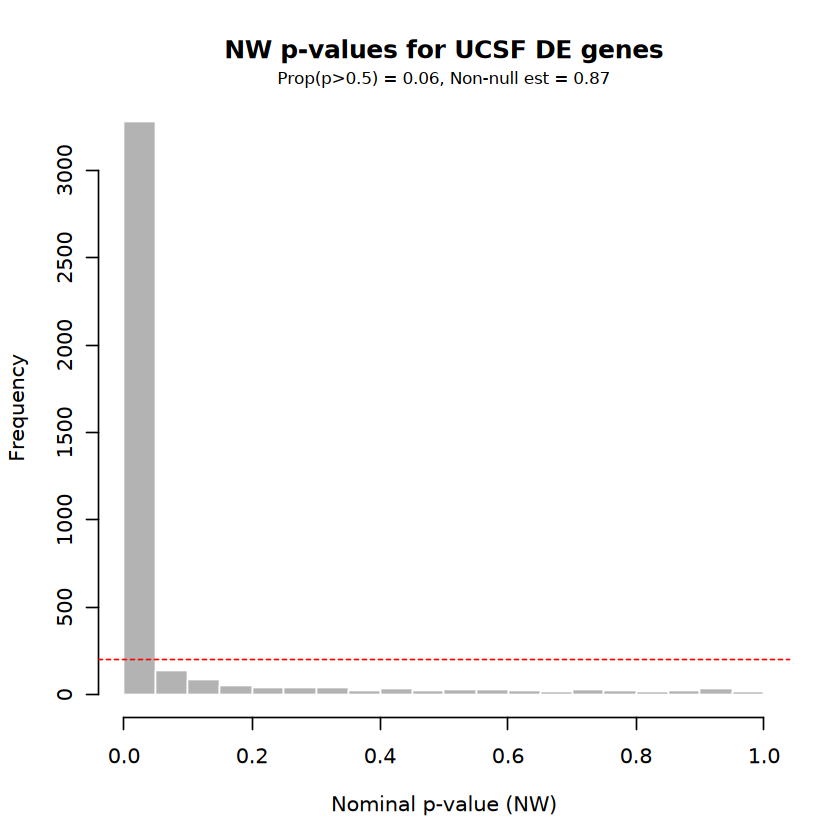

In [42]:
# UCSF DE set
src_genes <- ucsf
idx <- intersect(src_genes, rownames(ttNW))
pvals_in_NW <- ttNW[idx, "P.Value"]

# Proportion of p-values > 0.5
prop_gt_0_5 <- mean(pvals_in_NW > 0.5, na.rm = TRUE)

cat("Number of UCSF DE genes tested in NW:", length(pvals_in_NW), "\n")
cat("Proportion of NW p-values > 0.5:", round(prop_gt_0_5, 3), "\n")
cat("Heuristic non-null estimate (1 - 2*prop):", round(1 - 2*prop_gt_0_5, 3), "\n")

# Histogram
hist(pvals_in_NW, breaks = 20,
     main = "NW p-values for UCSF DE genes",
     xlab = "Nominal p-value (NW)",
     col = "grey70", border = "white")
abline(h = length(pvals_in_NW)/20, lty = 2, col = "red")
mtext(sprintf("Prop(p>0.5) = %.2f, Non-null est = %.2f",
              prop_gt_0_5, 1 - 2*prop_gt_0_5),
      side = 3, line = 0.5, cex = 0.8)


In [43]:

library(ggplot2)
library(ggpointdensity)
library(ragg)

# ---- Parameters ----
width_px  <- 1600
height_px <- 1400

# ---- Helper to build paired data and plots ----
make_pair_plots <- function(A, B, nameA, nameB, logFC_col = "logFC", qvalue_col = "qvalue", base_size = 12) {
  genes <- intersect(rownames(A), rownames(B))
  A2 <- A[genes, , drop = FALSE]
  B2 <- B[genes, , drop = FALSE]
  df <- data.frame(
    logFC_A = A2[, logFC_col],
    qvalue_A = A2[, qvalue_col],
    logFC_B = B2[, logFC_col],
    qvalue_B = B2[, qvalue_col]
  )

  df <- na.omit(df)
  eps <- .Machine$double.xmin
  df$qvalue_A <- pmax(df$qvalue_A, eps)
  df$qvalue_B <- pmax(df$qvalue_B, eps)

  p_qvalue <- ggplot(df, aes(-log10(qvalue_A), -log10(qvalue_B))) +
    geom_pointdensity() +
    scale_fill_gradient(trans = "log10") +
    ggtitle(sprintf("Scatter of -log10 Storey q-values: %s vs %s", nameA, nameB)) +
    xlab(nameA) + ylab(nameB) +
    theme_classic(base_size = base_size) +
    geom_abline(intercept = 0, slope = 1, color = "red", linetype = "dashed")

  p_lfc <- ggplot(df, aes(logFC_A, logFC_B)) +
    geom_pointdensity() +
    scale_fill_gradient(trans = "log10") +
    ggtitle(sprintf("Scatter of logFC: %s vs %s", nameA, nameB)) +
    xlab(nameA) + ylab(nameB) +
    theme_classic(base_size = base_size) +
    geom_abline(intercept = 0, slope = 1, color = "red", linetype = "dashed")

  list(p_qvalue = p_qvalue, p_lfc = p_lfc)
}

# ---- Run for all pairs and save ----
datasets <- list(JAX = ttJAX[, -1], UCSF = ttUCSF[, -1], NW = ttNW[, -1], MSK = ttMSK[, -1], NW_Parents = ttNW_parent[, -1])
pairs <- combn(names(datasets), 2, simplify = FALSE)

for (ab in pairs) {
  nameA <- ab[1]; nameB <- ab[2]
  plots <- make_pair_plots(datasets[[nameA]], datasets[[nameB]], nameA, nameB)

  # Save q-value plot
  ggsave(
    filename = file.path(personal_path, paste0("publication/", sprintf("GCM1_qvalue_%s-%s.png", nameA, nameB))),
    plot     = plots$p_qvalue,
    device   = ragg::agg_png,
    bg       = "transparent",
    width    = width_px,
    height   = height_px,
    units    = "px",
    dpi      = 300
  )

  # Save logFC plot
  ggsave(
    filename = file.path(personal_path, paste0("publication/", sprintf("GCM1_logFC_%s-%s.png", nameA, nameB))),
    plot     = plots$p_lfc,
    device   = ragg::agg_png,
    bg       = "transparent",
    width    = width_px,
    height   = height_px,
    units    = "px",
    dpi      = 300
  )

  message(sprintf("Saved plots for %s vs %s", nameA, nameB))
}


geom_pointdensity() using method='kde2d' due to large number of points (>20k). You may override this by setting method='neighbors'.

geom_pointdensity() using method='kde2d' due to large number of points (>20k). You may override this by setting method='neighbors'.

Saved plots for JAX vs UCSF

geom_pointdensity() using method='kde2d' due to large number of points (>20k). You may override this by setting method='neighbors'.

geom_pointdensity() using method='kde2d' due to large number of points (>20k). You may override this by setting method='neighbors'.

Saved plots for JAX vs NW

geom_pointdensity() using method='kde2d' due to large number of points (>20k). You may override this by setting method='neighbors'.

geom_pointdensity() using method='kde2d' due to large number of points (>20k). You may override this by setting method='neighbors'.

Saved plots for JAX vs MSK

geom_pointdensity() using method='kde2d' due to large number of points (>20k). You may override this by setting method

                 JAX       MSK        NW NW_parents      UCSF
JAX        1.0000000 0.8950939 0.5528289  0.7247097 0.7120681
MSK        0.8194005 1.0000000 0.5725297  0.7201138 0.7806436
NW         0.5137111 0.5221374 1.0000000  0.7620573 0.5244679
NW_parents 0.6879910 0.6661601 0.6306603  1.0000000 0.6647565
UCSF       0.6647829 0.7010541 0.5105886  0.6384381 1.0000000


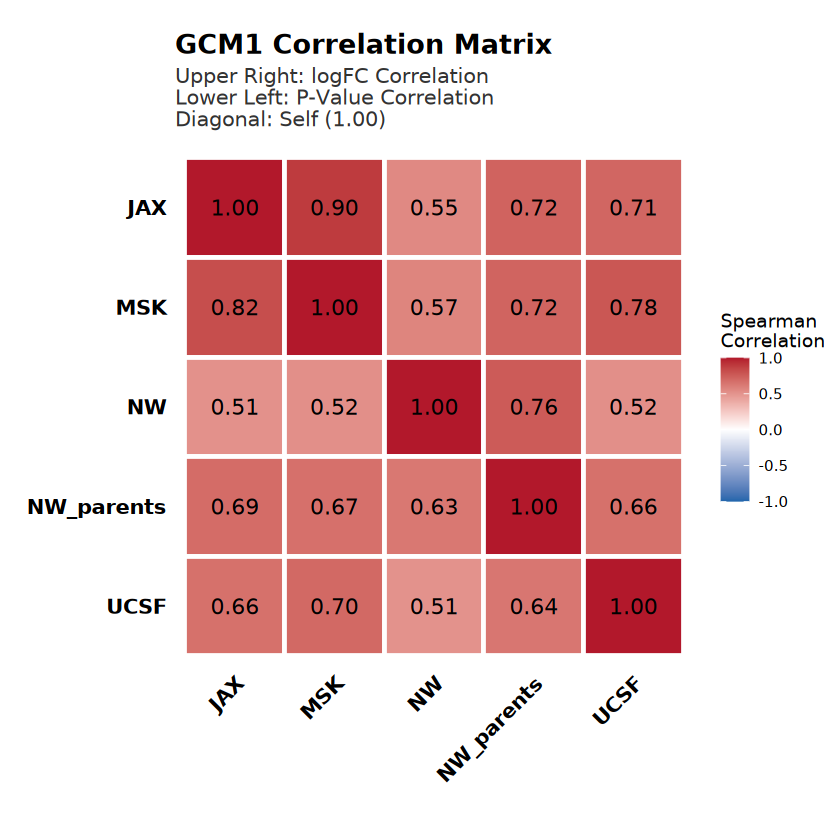

In [44]:
# 1. Put all your dataframes into a named list
# Make sure your 5 dataframes are named accordingly in your environment
df_list <- list(
  JAX = ttJAX,
  MSK = ttMSK,
  NW = ttNW,
  NW_parents = ttNW_parent,
  UCSF = ttUCSF
)

# 2. Find the common genes across all 5 datasets
# Assuming your gene names are the row names (as shown in your ttJAX snippet)
common_genes <- Reduce(intersect, lapply(df_list, rownames))

# Optional: If your gene names are actually in a column named 'V1', use this instead:
# common_genes <- Reduce(intersect, lapply(df_list, function(x) x$V1))

# 3. Extract the logFC and P.Value for these common genes
logFC_matrix <- sapply(df_list, function(df) df[common_genes, "logFC"])
pval_matrix  <- sapply(df_list, function(df) df[common_genes, "P.Value"])

# 4. Calculate the correlation matrices
# Note: "pearson" is standard, but you can change to "spearman" if you want rank-based correlation
cor_logFC <- cor(logFC_matrix, method = "spearman", use = "pairwise.complete.obs")
cor_pval  <- cor(pval_matrix, method = "spearman", use = "pairwise.complete.obs")

# 5. Initialize the combined matrix with 1s on the diagonal
n_datasets <- length(df_list)
combined_matrix <- matrix(1, nrow = n_datasets, ncol = n_datasets)
rownames(combined_matrix) <- names(df_list)
colnames(combined_matrix) <- names(df_list)

# 6. Fill the Upper Triangle with logFC correlations
combined_matrix[upper.tri(combined_matrix)] <- cor_logFC[upper.tri(cor_logFC)]

# 7. Fill the Lower Triangle with P.Value correlations
combined_matrix[lower.tri(combined_matrix)] <- cor_pval[lower.tri(cor_pval)]

# Print the final matrix
print(combined_matrix)

# --- Heatmap Visualization ---

# 1. Convert the matrix into a long-format dataframe suitable for ggplot
cor_df <- as.data.frame(as.table(combined_matrix))
colnames(cor_df) <- c("Dataset1", "Dataset2", "Correlation")

# 2. Reverse the factor order of Dataset1 so the diagonal goes from top-left to bottom-right
cor_df$Dataset1 <- factor(cor_df$Dataset1, levels = rev(rownames(combined_matrix)))
cor_df$Dataset2 <- factor(cor_df$Dataset2, levels = colnames(combined_matrix))

# 3. Create the Heatmap using ggplot2
plot_heatmap <- ggplot(data = cor_df, aes(x = Dataset2, y = Dataset1, fill = Correlation)) +
  geom_tile(color = "white", size = 1) +
  
  # Red/Blue color gradient (Standard for correlations: Red = +1, Blue = -1)
  scale_fill_gradient2(low = "#2166AC", mid = "white", high = "#B2182B", 
                       midpoint = 0, limit = c(-1, 1), name = "Spearman\nCorrelation") +
  
  # Add the correlation numbers inside the boxes (rounded to 2 decimal places)
  geom_text(aes(label = sprintf("%.2f", Correlation)), color = "black", size = 4.5) +
  
  # Clean minimal theme
  theme_minimal() +
  coord_fixed() + # Keeps the tiles perfectly square
  
  # Labels and Title (Explaining Upper vs Lower)
  labs(
    title = "GCM1 Correlation Matrix",
    subtitle = "Upper Right: logFC Correlation\nLower Left: P-Value Correlation\nDiagonal: Self (1.00)",
    x = "",
    y = ""
  ) +
  
  # Theme adjustments for font sizes and angles
  theme(
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, size = 12, face = "bold", color="black"),
    axis.text.y = element_text(size = 12, face = "bold", color="black"),
    panel.grid.major = element_blank(), # Remove grid lines
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 12, color = "gray20", margin = margin(b=10))
  )

# Display the plot
print(plot_heatmap)

# --- Optional: Save the plot ---
ggsave(
  filename = file.path(personal_path, paste0("publication/", "GCM1_Correlation_Heatmap.png")),
  plot     = plot_heatmap,
  device   = ragg::agg_png,
  bg       = "white",
  width    = 1800,
  height   = 1600,
  units    = "px",
  dpi      = 300
)


### PCA for all samples

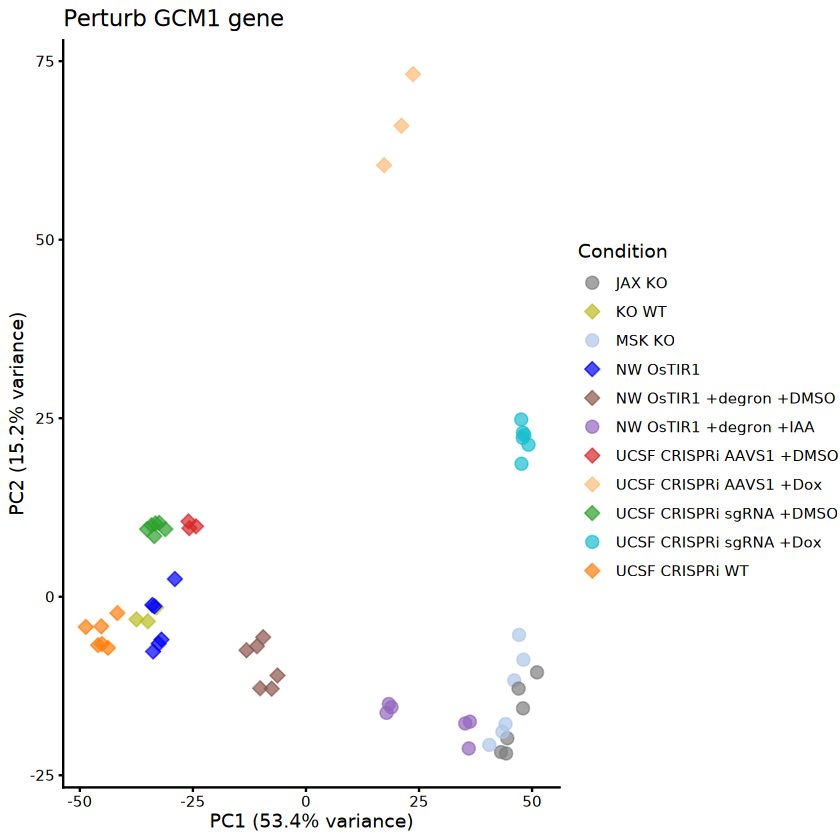

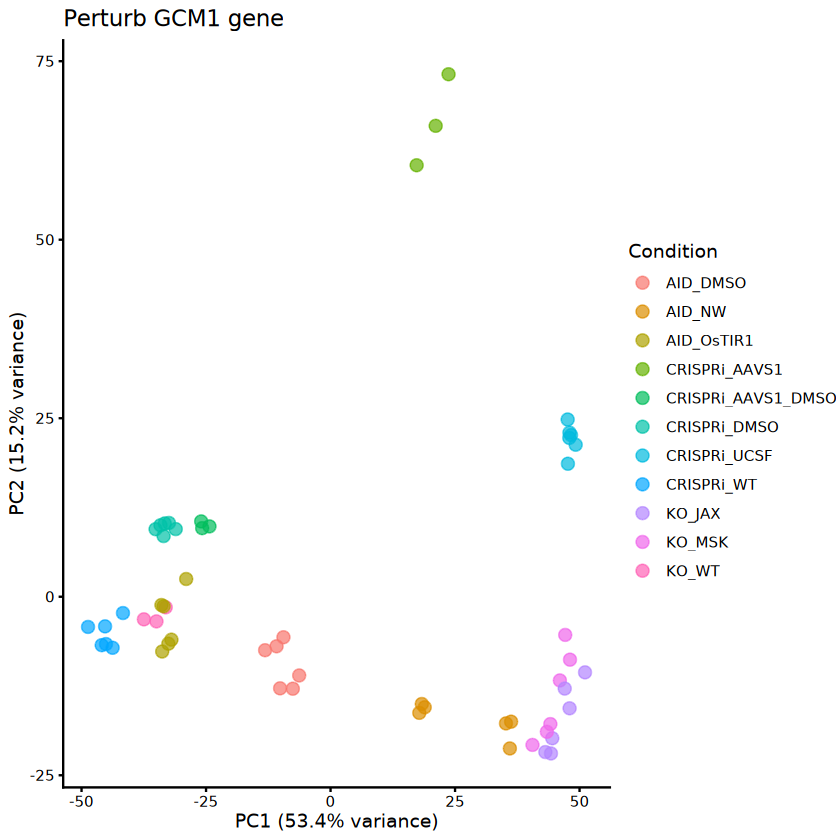

In [45]:
meta$read_depth = colSums(cts_dat)/1e6
meta$q75 = apply(cts_dat, 2, quantile, probs = 0.75)
meta$ko_strategy_clean <- gsub("CTRL_", "", meta$ko_strategy, ignore.case = TRUE)
meta$ko_strategy_clean[meta$model_condition == 'UCSF_Parent_DMSO_Rep'] = 'CRISPRi_AAVS1_DMSO'
my_colors <- c("blue", paletteer::paletteer_d("ggsci::category20_d3")[2:12])
names(my_colors) = unique(meta$ko_strategy_clean)
meta$run_id_short = meta$run_id

# PCA of all samples
y_pca <- DGEList(counts = cts_dat)
y_pca <- calcNormFactors(y_pca, method = "TMM")
logCPM_pca <- cpm(y_pca, log = TRUE)

gene_vars <- apply(logCPM_pca, 1, var)
gene_means <- apply(logCPM_pca, 1, mean)
top_genes <- order(gene_vars, decreasing = TRUE)[1:2500]
logCPM_top <- logCPM_pca[top_genes, ]

# mv_df <- data.frame(
#   Gene = rownames(logCPM_pca),
#   Mean = gene_means,
#   Variance = gene_vars,
#   Selected = rownames(logCPM_pca) %in% rownames(logCPM_top)
# )

# p_mean_var <- ggplot(mv_df, aes(x = Mean, y = Variance, color = Selected)) +
#   geom_point(alpha = 0.5, size = 1) +
#   # Add a trendline for the unselected background genes to show the baseline relationship
#   geom_smooth(data = subset(mv_df, Selected == FALSE), 
#               method = "loess", color = "blue", se = FALSE, linetype = "dashed") +
#   scale_color_manual(values = c("FALSE" = "grey70", "TRUE" = "red")) +
#   theme_classic(base_size = 14) +
#   labs(
#     title = "Mean-Variance Relationship (logCPM)",
#     subtitle = "Red points indicate top 2500 Highly Variable Genes",
#     x = "Mean Expression (log2-CPM)",
#     y = "Variance",
#     color = "Top 2500 HVG"
#   ) +
#   theme(legend.position = "bottom")

# print(p_mean_var)


pca_input <- t(logCPM_top)
sample_pca <- prcomp(pca_input, center = TRUE, scale. = TRUE)
pc_scores = sample_pca$x
eigen_vals = sample_pca$sdev^2
pvs = round(eigen_vals[1:5]/sum(eigen_vals)*100, 1)

PC_df = data.frame(pc_scores)
PC_df = cbind(PC_df, meta)

# 1. Define the specific name mappings
label_map <- c(
  "KO_WT"         = "KO WT",
  "AID_WT"        = "NW WT",
  "AID_DMSO"      = "NW OsTIR1 +degron +DMSO",
  "AID_NW"        = "NW OsTIR1 +degron +IAA",
  "AID_OsTIR1"    = "NW OsTIR1",
  "CRISPRi_AAVS1" = "UCSF CRISPRi AAVS1 +Dox",
  "CRISPRi_AAVS1_DMSO" = "UCSF CRISPRi AAVS1 +DMSO",
  "CRISPRi_DMSO"  = "UCSF CRISPRi sgRNA +DMSO",
  "CRISPRi_UCSF"  = "UCSF CRISPRi sgRNA +Dox",
  "CRISPRi_WT"    = "UCSF CRISPRi WT",
  "KO_JAX"        = "JAX KO",
  "KO_MSK"        = "MSK KO"
)

# 2. Apply the mapping to create a unified label column
PC_df$plot_label <- label_map[PC_df$ko_strategy_clean]
PC_df = PC_df[PC_df$plot_label != "NW WT", ]
# For any conditions not in the explicit list (e.g., AID_WT, KO_WT), 
# just replace the underscores with spaces
is_na_label <- is.na(PC_df$plot_label)
PC_df$plot_label[is_na_label] <- gsub("_", " ", PC_df$ko_strategy_clean[is_na_label])

# 3. Update 'my_colors' names so they match the new descriptive labels
new_color_names <- label_map[names(my_colors)]
is_na_color <- is.na(new_color_names)
new_color_names[is_na_color] <- gsub("_", " ", names(my_colors)[is_na_color])
names(my_colors) <- new_color_names

# 4. Generate a shape vector dynamically mapped to the new labels
# Assign 21 (circle) to GCM1 and 23 (diamond) to WT
shape_lookup <- ifelse(PC_df$ko_gene == "GCM1", 21, 23)
my_shapes <- setNames(shape_lookup, PC_df$plot_label)
my_shapes <- my_shapes[!duplicated(names(my_shapes))] # Ensure the list of shapes is unique

# 5. Build the plot
# Map color, fill, AND shape all to `plot_label` to force a single, merged legend
gPC = ggplot(PC_df, aes(x = PC1, y = PC2, color = plot_label, fill = plot_label, shape = plot_label)) +
  geom_point(size = 3, alpha = 0.7, stroke = 0.5) + 
  scale_color_manual(values = my_colors) +
  scale_fill_manual(values = my_colors) +
  scale_shape_manual(values = my_shapes) +
  labs(
    title = "Perturb GCM1 gene",
    x = sprintf("PC1 (%.1f%% variance)", pvs[1]),
    y = sprintf("PC2 (%.1f%% variance)", pvs[2]),
    # Use the same title for all aesthetics to keep the legend merged
    color = "Condition",
    fill  = "Condition",
    shape = "Condition"
  ) +
  theme_classic() + # Optional: Use to recreate the exact background from your image
  theme(
    legend.margin = margin(0, 0, 0, 0), 
    legend.box.just = "left", 
    legend.direction = "vertical" 
  )

print(gPC)

# Save the plot
width_px  = 1600
height_px = round(width_px * (3/5)) 

ggsave(
  filename = file.path(personal_path, paste0("/publication/", "GCM1_PCPlot_all_samples.png",sep='')),
  plot     = gPC,
  device   = ragg::agg_png,     
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300
)

ggplot(PC_df, aes(x = PC1, y = PC2, color = ko_strategy_clean)) +
  geom_point(size = 3, alpha = 0.7, stroke = 0.5) + 
  labs(
    title = "Perturb GCM1 gene",
    x = sprintf("PC1 (%.1f%% variance)", pvs[1]),
    y = sprintf("PC2 (%.1f%% variance)", pvs[2]),
    # Use the same title for all aesthetics to keep the legend merged
    color = "Condition"
  ) +
  theme_classic() + # Optional: Use to recreate the exact background from your image
  theme(
    legend.margin = margin(0, 0, 0, 0), 
    legend.box.just = "left", 
    legend.direction = "vertical" 
  )

### PCA for samples we are using

[1] 21878    45

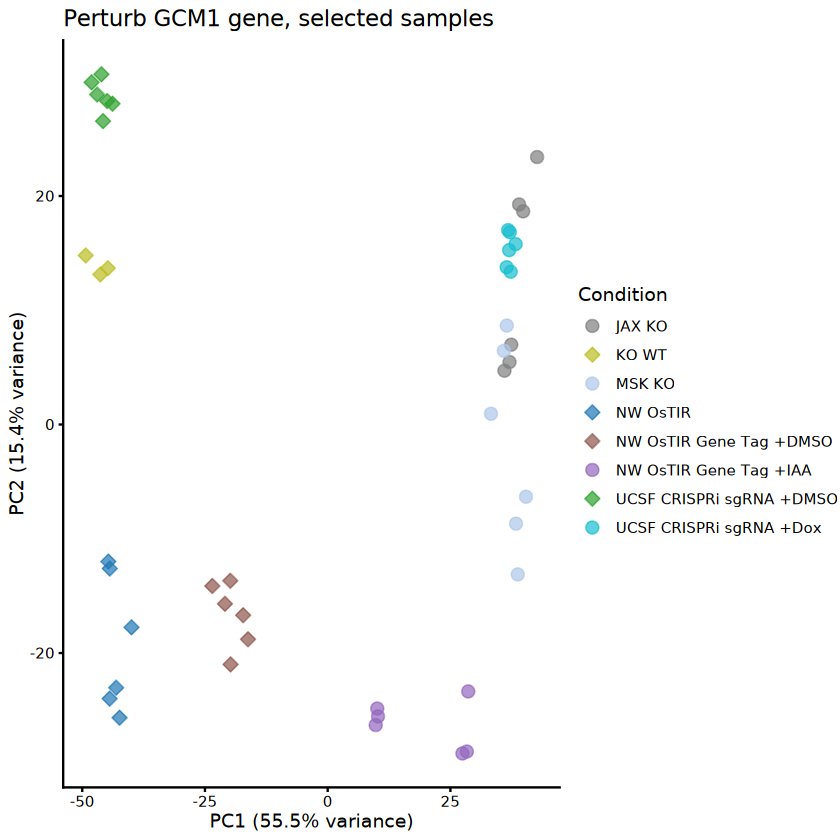

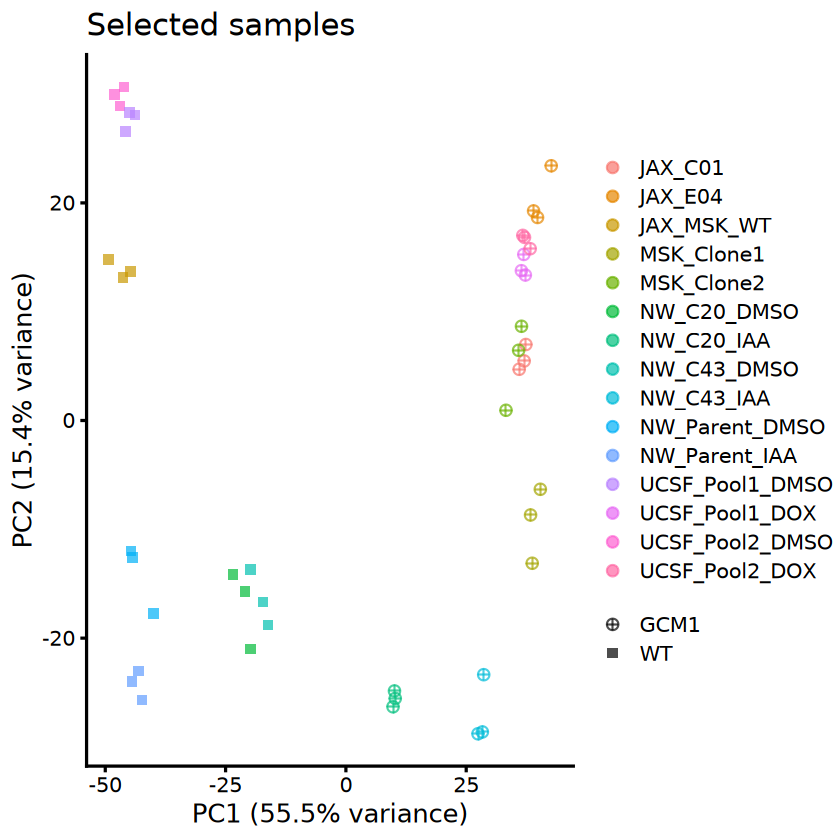

In [46]:
meta$ko_strategy_clean <- gsub("CTRL_", "", meta$ko_strategy, ignore.case = TRUE)
meta$ko_strategy_clean[meta$model_condition == 'UCSF_Parent_DMSO_Rep'] = 'CRISPRi_AAVS1_DMSO'
my_colors <- paletteer::paletteer_d("ggsci::category20_d3")[1:12]
names(my_colors) = unique(meta$ko_strategy_clean)
meta$run_id_short = meta$run_id

meta$ko_strategy_clean <- gsub("CTRL_", "", meta$ko_strategy, ignore.case = TRUE)
model1 = c("UCSF_Pool1_DMSO_Rep", "UCSF_Pool2_DMSO_Rep", "UCSF_Pool1_DOX_Rep", "UCSF_Pool2_DOX_Rep",
           "NW_C20_DMSO_Rep", "NW_C43_DMSO_Rep", "NW_C20_IAA_Rep", "NW_C43_IAA_Rep",
           "JAX_C01_Rep", "JAX_E04_Rep", "MSK_Clone1_Rep", "MSK_Clone2_Rep", "JAX_MSK_WT", 'NW_Parent_IAA_Rep', 'NW_Parent_DMSO_Rep')
sample2kp = which(meta$model_condition %in% model1)

cts_dat_m = cts_dat[,sample2kp]
meta_m    = meta[sample2kp,]

cts_dat_m_UCSF_NW = cts_dat_m
dim(cts_dat_m_UCSF_NW)
meta_m$clone = stringr::str_split_fixed(meta_m$model_condition, "_", 4)[, 2]
meta_m$clone[meta_m$clone == "MSK"] = "WT"

y_pca <- DGEList(counts = cts_dat_m_UCSF_NW)
y_pca <- calcNormFactors(y_pca, method = "TMM")
logCPM_pca <- cpm(y_pca, log = TRUE)

gene_vars <- apply(logCPM_pca, 1, var)
top_genes <- order(gene_vars, decreasing = TRUE)[1:2500]
logCPM_top <- logCPM_pca[top_genes, ]
pca_input <- t(logCPM_top)
sample_pca <- prcomp(pca_input, center = TRUE, scale. = TRUE)
pc_scores = sample_pca$x
eigen_vals = sample_pca$sdev^2
pvs = round(eigen_vals[1:5]/sum(eigen_vals)*100, 1)

PC_df = data.frame(pc_scores)
PC_df = cbind(PC_df, meta_m)

# 1. Define the specific name mappings
label_map <- c(
  "KO_WT"         = "KO WT",
  "AID_WT"        = "NW WT",
  "AID_DMSO"      = "NW OsTIR Gene Tag +DMSO",
  "AID_NW"        = "NW OsTIR Gene Tag +IAA",
  "AID_OsTIR1"    = "NW OsTIR",
  "CRISPRi_AAVS1" = "UCSF CRISPRi AAVS1 +Dox",
  "CRISPRi_AAVS1_DMSO" = "UCSF CRISPRi AAVS1 +DMSO",
  "CRISPRi_DMSO"  = "UCSF CRISPRi sgRNA +DMSO",
  "CRISPRi_UCSF"  = "UCSF CRISPRi sgRNA +Dox",
  "CRISPRi_WT"    = "UCSF CRISPRi WT",
  "KO_JAX"        = "JAX KO",
  "KO_MSK"        = "MSK KO"
)

# 2. Apply the mapping to create a unified label column
PC_df$plot_label <- label_map[PC_df$ko_strategy_clean]

# For any conditions not in the explicit list (e.g., AID_WT, KO_WT), 
# just replace the underscores with spaces
is_na_label <- is.na(PC_df$plot_label)
PC_df$plot_label[is_na_label] <- gsub("_", " ", PC_df$ko_strategy_clean[is_na_label])

# 3. Update 'my_colors' names so they match the new descriptive labels
new_color_names <- label_map[names(my_colors)]
is_na_color <- is.na(new_color_names)
new_color_names[is_na_color] <- gsub("_", " ", names(my_colors)[is_na_color])
names(my_colors) <- new_color_names

# 4. Generate a shape vector dynamically mapped to the new labels
# Assign 21 (circle) to GCM1 and 23 (diamond) to WT
shape_lookup <- ifelse(PC_df$ko_gene == "GCM1", 21, 23)
my_shapes <- setNames(shape_lookup, PC_df$plot_label)
my_shapes <- my_shapes[!duplicated(names(my_shapes))] # Ensure the list of shapes is unique


gPC = ggplot(PC_df, aes(x = PC1, y = PC2, color = plot_label, fill = plot_label, shape = plot_label)) +
  geom_point(size = 3, alpha = 0.7, stroke = 0.5) + 
  scale_color_manual(values = my_colors) +
  scale_fill_manual(values = my_colors) +
  scale_shape_manual(values = my_shapes) +
  labs(
    title = "Perturb GCM1 gene, selected samples",
    x = sprintf("PC1 (%.1f%% variance)", pvs[1]),
    y = sprintf("PC2 (%.1f%% variance)", pvs[2]),
    # Use the same title for all aesthetics to keep the legend merged
    color = "Condition",
    fill  = "Condition",
    shape = "Condition"
  ) +
  theme_classic() + # Optional: Use to recreate the exact background from your image
  theme(
    legend.margin = margin(0, 0, 0, 0), 
    legend.box.just = "left", 
    legend.direction = "vertical" 
  )

print(gPC)


width_px  = 1600
height_px = round(width_px * (3/5)) 

ggsave(
  filename = file.path(personal_path, paste0("/publication/", "GCM1_PCPlot_selected_samples.png",sep='')),
  plot     = gPC,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300,
)

PC_df$model_condition = gsub("_Rep", "", PC_df$model_condition)
gPC = ggplot(PC_df, aes(x = PC1, y = PC2, shape=ko_gene, color=model_condition)) +
  geom_point(size=2.5, alpha=0.7) +
  # Replace scale_shape_prism() with explicit manual shapes
  scale_shape_manual(values = c("GCM1" = 10, "WT" = 15)) +

  labs(color="KO type", shape ="KO gene") +
  xlab(sprintf("PC1 (%.1f%% variance)", pvs[1])) +
  ylab(sprintf("PC2 (%.1f%% variance)", pvs[2])) +
  ggtitle("Selected samples") +
  guides(
    color = guide_legend(title = NULL, order = 1),
    shape = guide_legend(title = NULL, order = 2)
  ) +
  theme(
    legend.margin = margin(0, 0, 0, 0),
    legend.box.just = "left",
    legend.direction = "vertical"
  )

print(gPC)
# 
# width_px  = 1920
# height_px = round(width_px * (3/4)) 
# 
# ggsave(
#   filename = file.path(personal_path, paste0("/publication/", "GCM1_PCPlot_selected_samples_detailed.png",sep='')),
#   plot     = gPC,
#   device   = ragg::agg_png,     # AGG backend, full alpha support
#   bg       = "transparent",
#   width    = width_px,
#   height   = height_px,
#   units    = "px",
#   dpi      = 300,
# )

[1] 21878    45

,Pathway,pval,padj,NES
,<chr>,<dbl>,<dbl>,<dbl>
1,MYC_TARGETS_V1,7.084685e-43,3.542343e-41,3.223122
2,OXIDATIVE_PHOSPHORYLATION,9.994711e-38,2.498678e-36,3.090995
3,E2F_TARGETS,2.551035e-31,4.251726e-30,2.962472
4,G2M_CHECKPOINT,1.518599e-23,1.898249e-22,2.713345
5,MYC_TARGETS_V2,2.366928e-13,1.690663e-12,2.652341
6,DNA_REPAIR,1.475127e-13,1.229272e-12,2.383687


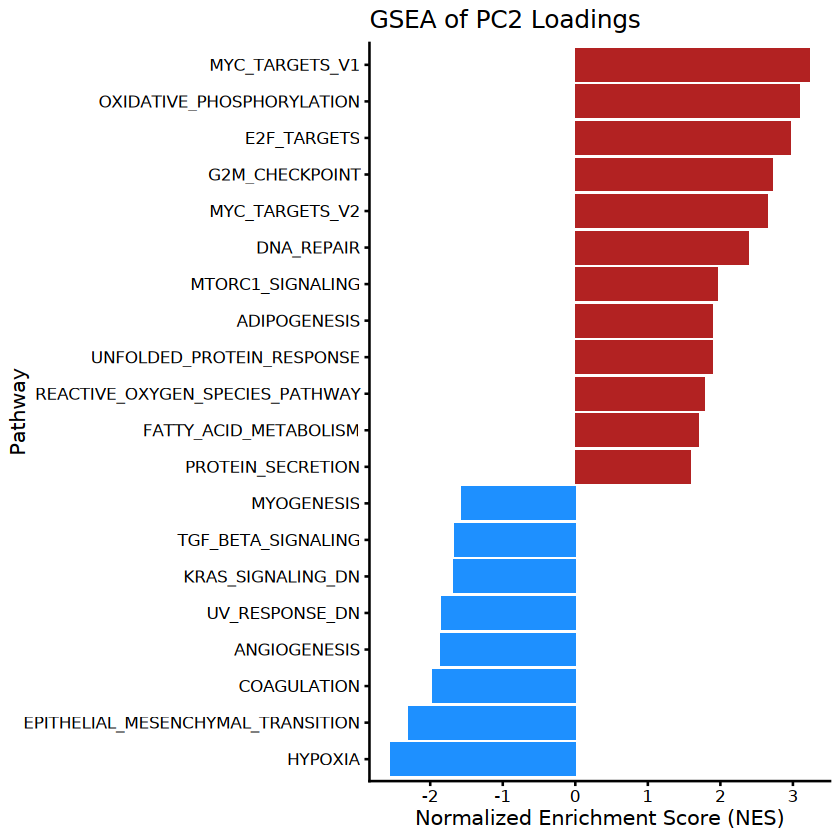

In [47]:
library(fgsea)
library(msigdbr)
library(ggplot2)
library(dplyr)

meta$ko_strategy_clean <- gsub("CTRL_", "", meta$ko_strategy, ignore.case = TRUE)
meta$ko_strategy_clean[meta$model_condition == 'UCSF_Parent_DMSO_Rep'] = 'CRISPRi_AAVS1_DMSO'
my_colors <- paletteer::paletteer_d("ggsci::category20_d3")[1:12]
names(my_colors) = unique(meta$ko_strategy_clean)
meta$run_id_short = meta$run_id

meta$ko_strategy_clean <- gsub("CTRL_", "", meta$ko_strategy, ignore.case = TRUE)
model1 = c("UCSF_Pool1_DMSO_Rep", "UCSF_Pool2_DMSO_Rep", "UCSF_Pool1_DOX_Rep", "UCSF_Pool2_DOX_Rep",
           "NW_C20_DMSO_Rep", "NW_C43_DMSO_Rep", "NW_C20_IAA_Rep", "NW_C43_IAA_Rep",
           "JAX_C01_Rep", "JAX_E04_Rep", "MSK_Clone1_Rep", "MSK_Clone2_Rep", "JAX_MSK_WT", 'NW_Parent_IAA_Rep', 'NW_Parent_DMSO_Rep')
sample2kp = which(meta$model_condition %in% model1)

cts_dat_m = cts_dat[,sample2kp]
meta_m    = meta[sample2kp,]

cts_dat_m_UCSF_NW = cts_dat_m
dim(cts_dat_m_UCSF_NW)
meta_m$clone = stringr::str_split_fixed(meta_m$model_condition, "_", 4)[, 2]
meta_m$clone[meta_m$clone == "MSK"] = "WT"

y_pca <- DGEList(counts = cts_dat_m_UCSF_NW)
y_pca <- calcNormFactors(y_pca, method = "TMM")
logCPM_pca <- cpm(y_pca, log = TRUE)

gene_vars <- apply(logCPM_pca, 1, var)
top_genes <- order(gene_vars, decreasing = TRUE)
logCPM_top <- logCPM_pca[top_genes, ]
pca_input <- t(logCPM_top)
sample_pca <- prcomp(pca_input, center = TRUE, scale. = TRUE)

pc2_loadings = sample_pca$rotation[, 2]
# 1. Prepare your ranked list
# Sort the loadings in decreasing order (highest positive to lowest negative)
pc2_ranked <- sort(pc2_loadings, decreasing = TRUE)

# 2. Get Gene Sets from MSigDB
m_df <- msigdbr(species = "Homo sapiens", category = "H") 

# THE FIX: Split by 'ensembl_gene' instead of 'gene_symbol'
pathways_ensembl <- split(x = m_df$ensembl_gene, f = m_df$gs_name)

# 3. Run fgsea
# Now both your ranked list and the pathways use Ensembl IDs
fgsea_res <- fgsea(pathways = pathways_ensembl, 
                   stats    = pc2_ranked,
                   minSize  = 15,
                   maxSize  = 500)

# 4. Clean up and sort the results
fgsea_res <- fgsea_res %>%
  as.data.frame() %>%
  arrange(desc(NES)) %>%
  mutate(Pathway = gsub("HALLMARK_", "", pathway)) 

# View the top significant pathways
head(fgsea_res[fgsea_res$padj < 0.05, c("Pathway", "pval", "padj", "NES")])

# 5. Plot the top pathways
top_pathways <- fgsea_res %>% 
  filter(padj < 0.05) %>% 
  arrange(abs(NES)) %>% 
  tail(20) # Grab the top 20 most extreme pathways

p_gsea = ggplot(top_pathways, aes(x = NES, y = reorder(Pathway, NES), fill = NES > 0)) +
  geom_col() +
  scale_fill_manual(values = c("TRUE" = "firebrick", "FALSE" = "dodgerblue")) +
  theme_classic(base_size = 12) +
  labs(
    title = "GSEA of PC2 Loadings",
    x = "Normalized Enrichment Score (NES)",
    y = "Pathway",
    fill = "Positive PC2"
  ) +
  theme(legend.position = "none")

print(p_gsea)

# ggsave(...)

### DE analysis for MSK, compare one clone with two clones

In [48]:
meta$model_condition = stringr::str_sub(meta$model_system, start = 1, end = -2)

df_size = NULL
model1 = c("JAX_C01_Rep", "JAX_E04_Rep", "MSK_Clone1_Rep", "MSK_Clone2_Rep", "JAX_MSK_WT")
sample2kp = which(meta$model_condition %in% model1)

cts_dat_m = cts_dat[,sample2kp]
meta_m    = meta[sample2kp,]

table(meta_m$ko_strategy)
stopifnot(all(meta_m$file_id == colnames(cts_dat_m)))
  
## Generate sample information matrix
cols2kp = c("model_condition", "ko_strategy", "ko_gene", 
            "run_id", "run_id_short", "timepoint", "q75")
sample_info = meta_m[,cols2kp]
colnames(sample_info)[which(colnames(sample_info)=="timepoint")] = "day"

dim(sample_info)
sample_info[1:2,]
  

model1 = c("MSK_Clone1_Rep", "JAX_MSK_WT")
sample2kp = which(meta_m$model_condition %in% model1)
cts_dat_m_MSK_WT = cts_dat_m[,sample2kp]
sample_info_MSK_WT = sample_info[sample2kp,]
sample_info_MSK_WT$clone = stringr::str_split_fixed(sample_info_MSK_WT$model_condition, "_", 4)[, 2]

# ---- inputs ----
counts  <- cts_dat_m_MSK_WT
colData <- sample_info_MSK_WT
rownames(colData) = colnames(counts)
stopifnot(all(colnames(counts) == rownames(colData)))

# ---- group factor: WT vs KO ----
group <- ifelse(colData$ko_strategy == "CTRL_KO_WT" | colData$ko_gene == "WT" | colData$model_condition == "JAX_MSK_WT",
                "WT", "KO")
group <- factor(group, levels = c("WT","KO"))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT","KO")

# ---- block vector: KO keep clone IDs; WT each unique ----
isWT  <- group == "WT"
block <- as.character(colData$clone)
block[isWT] <- paste0("WT_", seq_len(sum(isWT)))

# ---- normalization + voom (quality weights optional) ----
y2 <- DGEList(counts)
y2 <- calcNormFactors(y2)
v2 <- voom(y2, design2, plot = FALSE)

# ---- optional duplicate-correlation fit ----
fitMSK <- fit_limma_with_optional_duplicate_correlation(v2, design2, block = block, fit_label = "fitMSK")

# ---- KO vs WT contrast ----
L2 <- makeContrasts(KOvsWT = KO - WT, levels = design2)
fitMSK <- eBayes(contrasts.fit(fitMSK, L2))
ttMSK1   <- topTable(fitMSK, coef = "KOvsWT", number = Inf)
ttMSK1_before_max_mean_filter <- add_qvalue_and_cpm(ttMSK1, counts, group = group, apply_cpm_filter = FALSE)
ttMSK1 <- filter_by_max_mean_cpm(ttMSK1_before_max_mean_filter, min_cpm = 1)




model1 = c("MSK_Clone2_Rep", "JAX_MSK_WT")
sample2kp = which(meta_m$model_condition %in% model1)
cts_dat_m_MSK_WT = cts_dat_m[,sample2kp]
sample_info_MSK_WT = sample_info[sample2kp,]
sample_info_MSK_WT$clone = stringr::str_split_fixed(sample_info_MSK_WT$model_condition, "_", 4)[, 2]

# ---- inputs ----
counts  <- cts_dat_m_MSK_WT
colData <- sample_info_MSK_WT
rownames(colData) = colnames(counts)
stopifnot(all(colnames(counts) == rownames(colData)))

# ---- group factor: WT vs KO ----
group <- ifelse(colData$ko_strategy == "CTRL_KO_WT" | colData$ko_gene == "WT" | colData$model_condition == "JAX_MSK_WT",
                "WT", "KO")
group <- factor(group, levels = c("WT","KO"))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT","KO")

# ---- block vector: KO keep clone IDs; WT each unique ----
isWT  <- group == "WT"
block <- as.character(colData$clone)
block[isWT] <- paste0("WT_", seq_len(sum(isWT)))

# ---- normalization + voom (quality weights optional) ----
y2 <- DGEList(counts)
y2 <- calcNormFactors(y2)
v2 <- voom(y2, design2, plot = FALSE)

# ---- optional duplicate-correlation fit ----
fitMSK <- fit_limma_with_optional_duplicate_correlation(v2, design2, block = block, fit_label = "fitMSK")

# ---- KO vs WT contrast ----
L2 <- makeContrasts(KOvsWT = KO - WT, levels = design2)
fitMSK <- eBayes(contrasts.fit(fitMSK, L2))
ttMSK2   <- topTable(fitMSK, coef = "KOvsWT", number = Inf)
ttMSK2_before_max_mean_filter <- add_qvalue_and_cpm(ttMSK2, counts, group = group, apply_cpm_filter = FALSE)
ttMSK2 <- filter_by_max_mean_cpm(ttMSK2_before_max_mean_filter, min_cpm = 1)



CTRL_KO_WT     KO_JAX     KO_MSK 
         3          6          6 

[1] 15  7

,model_condition,ko_strategy,ko_gene,run_id,run_id_short,day,q75
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>
17,JAX_C01_Rep,KO_JAX,GCM1,20250616_GT25-RobsonP-99,20250616_GT25-RobsonP-99,6,1033
21,JAX_E04_Rep,KO_JAX,GCM1,20250616_GT25-RobsonP-99,20250616_GT25-RobsonP-99,6,1063


Skipping duplicate-correlation for fitMSK: only 1 repeated clone/block level(s).

Skipping duplicate-correlation for fitMSK: only 1 repeated clone/block level(s).



In [49]:
# ---- LogFC Scatter Plot: MSK Clone 1 vs Clone 2 ----
# Match rownames to ensure genes align perfectly
ttMSK1_plot = ttMSK1[match(rownames(ttMSK2), rownames(ttMSK1)), ]
ttMSK1_plot$logFC.clone2 = ttMSK2$logFC

p1_logfc = ggplot(ttMSK1_plot, aes(logFC, logFC.clone2)) +
    geom_pointdensity() +
    ggtitle(sprintf("Scatter of logFC: %s vs %s", "MSK Clone 1", "MSK Clone 2")) +
    xlab("MSK Clone 1") + ylab("MSK Clone 2") +
    theme_classic(base_size = 15) +
    geom_abline(intercept = 0, slope = 1, color = "red", linetype = "dashed")

ggsave(
  filename = file.path(personal_path, paste0("/publication/", "GCM1_logFC_MSK_Clone1vsClone2.png",sep='')),
  plot     = p1_logfc,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300
)

# ---- Q-Value Scatter Plot: MSK Clone 1 vs Clone 2 ----
# Using the same matched dataframe
ttMSK1_plot$qvalue.clone2 = ttMSK2$qvalue

p1_qvalue = ggplot(ttMSK1_plot, aes(-log10(qvalue), -log10(qvalue.clone2))) +
    geom_pointdensity() +
    ggtitle(sprintf("-log10 Storey q-values: %s vs %s", "MSK Clone 1", "MSK Clone 2")) +
    xlab("MSK Clone 1") + ylab("MSK Clone 2") +
    theme_classic(base_size = 15) +
    geom_abline(intercept = 0, slope = 1, color = "red", linetype = "dashed")

ggsave(
  filename = file.path(personal_path, paste0("/publication/", "GCM1_qvalue_MSK_Clone1vsClone2.png",sep='')),
  plot     = p1_qvalue,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300
)


Warning message:
“Removed 80 rows containing missing values or values outside the scale range
(`stat_pointdensity()`).”
Warning message:
“Removed 80 rows containing missing values or values outside the scale range
(`stat_pointdensity()`).”


### DE analysis for NW

In [50]:
meta$model_condition = stringr::str_sub(meta$model_system, start = 1, end = -2)

df_size = NULL
model1 = c("UCSF_Pool1_DMSO_Rep", "UCSF_Pool2_DMSO_Rep", "UCSF_Pool1_DOX_Rep", "UCSF_Pool2_DOX_Rep",
           "NW_C20_DMSO_Rep", "NW_C43_DMSO_Rep", "NW_C20_IAA_Rep", "NW_C43_IAA_Rep", "NW_Parent_IAA_Rep", 'NW_Parent_DMSO_Rep')
sample2kp = which(meta$model_condition %in% model1)

cts_dat_m = cts_dat[,sample2kp]
meta_m    = meta[sample2kp,]

table(meta_m$ko_strategy)
stopifnot(all(meta_m$file_id == colnames(cts_dat_m)))
  
## Generate sample information matrix
cols2kp = c("model_condition", "ko_strategy", "ko_gene", 
            "run_id", "run_id_short", "timepoint", "q75")
sample_info = meta_m[,cols2kp]
colnames(sample_info)[which(colnames(sample_info)=="timepoint")] = "day"

dim(sample_info)
sample_info[1:2,]
  




model1 = c("NW_C20_DMSO_Rep", "NW_C43_DMSO_Rep", "NW_C20_IAA_Rep", "NW_C43_IAA_Rep")
sample2kp = which(meta_m$model_condition %in% model1)
cts_dat_m_NW = cts_dat_m[,sample2kp]
sample_info_NW = sample_info[sample2kp,]
sample_info_NW$clone = stringr::str_split_fixed(sample_info_NW$model_condition, "_", 4)[, 2]


# ---- inputs ----
counts  <- cts_dat_m_NW
colData <- sample_info_NW
rownames(colData) = colnames(counts)
stopifnot(all(colnames(counts) == rownames(colData)))

# ---- group factor: WT vs KO ----
group <- ifelse(colData$ko_gene == "WT",
                "WT", "KO")
group <- factor(group, levels = c("WT","KO"))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT","KO")

# ---- block vector: KO keep clone IDs; WT each unique ----
block <- as.character(colData$clone)
block = paste(block, group, sep = "_")

# ---- normalization + voom (quality weights optional) ----
y2 <- DGEList(counts)
y2 <- calcNormFactors(y2)
v2 <- voom(y2, design2, plot = FALSE)

# ---- optional duplicate-correlation fit ----
fitNW <- fit_limma_with_optional_duplicate_correlation(v2, design2, block = block, fit_label = "fitNW")

# ---- KO vs WT contrast ----
L2 <- makeContrasts(KOvsWT = KO - WT, levels = design2)
fitNW1 <- eBayes(contrasts.fit(fitNW, L2))
ttNW1   <- topTable(fitNW1, coef = "KOvsWT", number = Inf)
ttNW1_before_max_mean_filter <- add_qvalue_and_cpm(ttNW1, counts, group = group, apply_cpm_filter = FALSE)
ttNW1 <- filter_by_max_mean_cpm(ttNW1_before_max_mean_filter, min_cpm = 1)



model1 = c("NW_C20_DMSO_Rep", "NW_C43_DMSO_Rep", "NW_C20_IAA_Rep", "NW_C43_IAA_Rep", 'NW_Parent_IAA_Rep', 'NW_Parent_DMSO_Rep')
sample2kp = which(meta_m$model_condition %in% model1)
cts_dat_m_NW = cts_dat_m[,sample2kp]
sample_info_NW = sample_info[sample2kp,]
sample_info_NW$clone = stringr::str_split_fixed(sample_info_NW$model_condition, "_", 4)[, 2]


# ---- inputs ----
counts  <- cts_dat_m_NW
colData <- sample_info_NW
rownames(colData) = colnames(counts)
stopifnot(all(colnames(counts) == rownames(colData)))

# ---- group factor: WT vs KO ----
group <- ifelse(colData$ko_gene == "WT",
                "WT", "KO")
group <- factor(group, levels = c("WT","KO"))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT","KO")

# ---- block vector: KO keep clone IDs; WT each unique ----
block <- as.character(colData$clone)
block = paste(block, group, sep = "_")

# ---- normalization + voom (quality weights optional) ----
y2 <- DGEList(counts)
y2 <- calcNormFactors(y2)
v2 <- voom(y2, design2, plot = FALSE)

# ---- optional duplicate-correlation fit ----
fitNW <- fit_limma_with_optional_duplicate_correlation(v2, design2, block = block, fit_label = "fitNW")

# ---- KO vs WT contrast ----
L2 <- makeContrasts(KOvsWT = KO - WT, levels = design2)
fitNW2 <- eBayes(contrasts.fit(fitNW, L2))
ttNW2   <- topTable(fitNW2, coef = "KOvsWT", number = Inf)
ttNW2_before_max_mean_filter <- add_qvalue_and_cpm(ttNW2, counts, group = group, apply_cpm_filter = FALSE)
ttNW2 <- filter_by_max_mean_cpm(ttNW2_before_max_mean_filter, min_cpm = 1)





model1 = c("NW_C20_IAA_Rep", "NW_C43_IAA_Rep", 'NW_Parent_IAA_Rep', 'NW_Parent_DMSO_Rep')
sample2kp = which(meta_m$model_condition %in% model1)
cts_dat_m_NW = cts_dat_m[,sample2kp]
sample_info_NW = sample_info[sample2kp,]
sample_info_NW$clone = stringr::str_split_fixed(sample_info_NW$model_condition, "_", 4)[, 2]


# ---- inputs ----
counts  <- cts_dat_m_NW
colData <- sample_info_NW
rownames(colData) = colnames(counts)
stopifnot(all(colnames(counts) == rownames(colData)))

# ---- group factor: WT vs KO ----
group <- ifelse(colData$ko_gene == "WT",
                "WT", "KO")
group <- factor(group, levels = c("WT","KO"))

design2 <- model.matrix(~ 0 + group)
colnames(design2) <- c("WT","KO")

# ---- block vector: KO keep clone IDs; WT each unique ----
block <- as.character(colData$clone)
block = paste(block, group, sep = "_")

# ---- normalization + voom (quality weights optional) ----
y2 <- DGEList(counts)
y2 <- calcNormFactors(y2)
v2 <- voom(y2, design2, plot = FALSE)

# ---- optional duplicate-correlation fit ----
fitNW <- fit_limma_with_optional_duplicate_correlation(v2, design2, block = block, fit_label = "fitNW")

# ---- KO vs WT contrast ----
L2 <- makeContrasts(KOvsWT = KO - WT, levels = design2)
fitNW3 <- eBayes(contrasts.fit(fitNW, L2))
ttNW3   <- topTable(fitNW3, coef = "KOvsWT", number = Inf)
ttNW3_before_max_mean_filter <- add_qvalue_and_cpm(ttNW3, counts, group = group, apply_cpm_filter = FALSE)
ttNW3 <- filter_by_max_mean_cpm(ttNW3_before_max_mean_filter, min_cpm = 1)



           AID_NW      CRISPRi_UCSF     CTRL_AID_DMSO   CTRL_AID_OsTIR1 
                6                 6                 6                 6 
CTRL_CRISPRi_DMSO 
                6 

[1] 30  7

,model_condition,ko_strategy,ko_gene,run_id,run_id_short,day,q75
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>
24,NW_Parent_IAA_Rep,CTRL_AID_OsTIR1,WT,20250616_GT25-RobsonP-99,20250616_GT25-RobsonP-99,6,975.75
58,NW_Parent_DMSO_Rep,CTRL_AID_OsTIR1,WT,20250616_GT25-RobsonP-99,20250616_GT25-RobsonP-99,6,833.00


Estimated duplicate-correlation for fitNW: 0.144

Estimated duplicate-correlation for fitNW: 0.315

Estimated duplicate-correlation for fitNW: 0.118



In [51]:
ttNW1$threshold <- ttNW1$q75_pass &
  !is.na(ttNW1$qvalue) & ttNW1$qvalue < 0.05 &
  is.finite(ttNW1$logFC) & abs(ttNW1$logFC) > 1 &
  is.finite(ttNW1$max_mean_CPM) & ttNW1$max_mean_CPM >= 1
ttNW2$threshold <- ttNW2$q75_pass &
  !is.na(ttNW2$qvalue) & ttNW2$qvalue < 0.05 &
  is.finite(ttNW2$logFC) & abs(ttNW2$logFC) > 1 &
  is.finite(ttNW2$max_mean_CPM) & ttNW2$max_mean_CPM >= 1
ttNW3$threshold <- ttNW3$q75_pass &
  !is.na(ttNW3$qvalue) & ttNW3$qvalue < 0.05 &
  is.finite(ttNW3$logFC) & abs(ttNW3$logFC) > 1 &
  is.finite(ttNW3$max_mean_CPM) & ttNW3$max_mean_CPM >= 1
ttNW1Sig = ttNW1[ttNW1$threshold, ]
ttNW2Sig = ttNW2[ttNW2$threshold, ]
ttNW3Sig = ttNW3[ttNW3$threshold, ]

print("Number of overlaps between NW with only DMSO and NW with DMSO + parents")
length(intersect(rownames(ttNW1Sig), rownames(ttNW2Sig)))
print("Number of sig. genes for NW with only DMSO")
nrow(ttNW1Sig)
print("Number of sig. genes for NW with DMSO + parents")
nrow(ttNW2Sig)


print("Number of overlaps between NW with only DMSO and NW with parents")
length(intersect(rownames(ttNW1Sig), rownames(ttNW3Sig)))
print("Number of sig. genes for NW with only DMSO")
nrow(ttNW1Sig)
print("Number of sig. genes for NW with parents")
nrow(ttNW3Sig)


[1] "Number of overlaps between NW with only DMSO and NW with DMSO + parents"


[1] 927

[1] "Number of sig. genes for NW with only DMSO"


[1] 1060

[1] "Number of sig. genes for NW with DMSO + parents"


...

[1] 831

[1] "Number of sig. genes for NW with only DMSO"


[1] 1060

[1] "Number of sig. genes for NW with parents"


[1] 1982

### Volcano plot visualization

In [52]:
# Add a significance column for coloring
ttNW3$threshold <- ttNW3$q75_pass &
  !is.na(ttNW3$qvalue) & ttNW3$qvalue < 0.05 &
  is.finite(ttNW3$logFC) & abs(ttNW3$logFC) > 1 &
  is.finite(ttNW3$max_mean_CPM) & ttNW3$max_mean_CPM >= 1

p2 = ggplot(ttNW3, aes(x = logFC, y = -log10(qvalue))) +
  geom_point(aes(color = threshold), alpha = 0.6, size = 1.5) +
  scale_color_manual(values = c("FALSE" = "grey70", "TRUE" = "red")) +
  theme_minimal(base_size = 14) +
  labs(title = "Volcano Plot: KO IAA vs Parents for NW",
       x = "log2 Fold Change",
       y = "-log10(Storey q-value)") +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "black") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black")

width_px  = 1920
height_px = round(width_px * (3/4)) 

ggsave(
  filename = file.path(personal_path, paste0("/publication/", "GCM1_VolcanoPlot_NW_withParents.png",sep='')),
  plot     = p2,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",       
  dpi      = 300,
)


In [53]:
ttNW1 = ttNW1[match(rownames(ttNW3), rownames(ttNW1)), ]
ttNW1$logFC.parent = ttNW3$logFC

p1 = ggplot(ttNW1, aes(logFC, logFC.parent)) +
    geom_pointdensity() +
    ggtitle(sprintf("Scatter of logFC: %s vs %s", "DMSO", "Parent")) +
    xlab("DMSO") + ylab("Parent") +
    theme_classic(base_size = 15) +
    geom_abline(intercept = 0, slope = 1, color = "red", linetype = "dashed")

ggsave(
  filename = file.path(personal_path, paste0("/publication/", "GCM1_logFC_NW_DMSOvsParent.png",sep='')),
  plot     = p1,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300,
)

Warning message:
“Removed 179 rows containing missing values or values outside the scale range
(`stat_pointdensity()`).”


In [54]:
ttNW1 = ttNW1[match(rownames(ttNW3), rownames(ttNW1)), ]
ttNW1$qvalue.parent = ttNW3$qvalue

p1 = ggplot(ttNW1, aes(-log10(qvalue), -log10(qvalue.parent))) +
    geom_pointdensity() +
    ggtitle(sprintf("-log10 Storey q-values: %s vs %s", "DMSO", "Parent")) +
    xlab("DMSO") + ylab("Parent") +
    theme_classic(base_size = 15) +
    geom_abline(intercept = 0, slope = 1, color = "red", linetype = "dashed")

ggsave(
  filename = file.path(personal_path, paste0("/publication/", "GCM1_qvalue_NW_DMSOvsParent.png",sep='')),
  plot     = p1,
  device   = ragg::agg_png,     # AGG backend, full alpha support
  bg       = "transparent",
  width    = width_px,
  height   = height_px,
  units    = "px",
  dpi      = 300,
)


Warning message:
“Removed 179 rows containing missing values or values outside the scale range
(`stat_pointdensity()`).”
